# Exploration temporaire — régularité mensuelle TGV AQST

Exploration du **CSV local fourni**, préparée le **6 octobre 2026**. Les cellules sont exécutées : les tableaux et les graphiques sont déjà visibles. Le fichier source reste intact. Relancer « Run all » actualise l'analyse.

Une observation correspond à un **mois × service × gare de départ × gare d'arrivée**. Le sens du trajet compte. Il s'agit d'agrégats mensuels par liaison, sans données individuelles de train, de voyageur ou de jour.

**Lecture des indicateurs.** La [documentation SNCF](https://data.sncf.com/explore/dataset/regularite-mensuelle-tgv-aqst/analyze/) décrit une régularité composite à l'arrivée : seuils de 5, 10 ou 15 minutes selon la durée du parcours. Les comptes au départ et à l'arrivée ne décrivent donc pas nécessairement le même événement. Les champs « > 15 min » portent une précision liée aux liaisons concurrencées par avion dans le [schéma SNCF](https://ressources.data.sncf.com/explore/dataset/regularite-mensuelle-tgv-aqst/).

**Périmètre des agrégats.** SNCF indique qu'un même TGV peut apparaître dans plusieurs liaisons. Les sommes ci-dessous mesurent des **circulations déclarées par liaison**, pas des trains uniques. Les taux pondérés sont des indicateurs descriptifs de ce fichier et **ne constituent pas la régularité globale TGV**. Les différences temporelles et entre services peuvent aussi refléter des changements de périmètre.

Parcours : synthèse → structure → distributions → qualité → temps → liaisons → causes → corrélations → commentaires → conclusions.

## 1. Chargement et conventions

Le CSV est lu en UTF-8, avec un séparateur `;`. Certains commentaires contiennent des retours à la ligne entre guillemets : compter les lignes physiques du fichier ne donne pas le nombre d'observations.

Dépendances : `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `ipykernel`. Si le noyau choisi ne les possède pas, exécuter au besoin `%pip install pandas numpy matplotlib seaborn scipy ipykernel`, puis redémarrer le noyau. Aucune installation n'est lancée par le notebook.

In [1]:
from pathlib import Path
import sys, io, csv, hashlib, importlib.metadata, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, Markdown

%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 12, 'axes.labelsize': 10})
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

def table(frame, n=None, decimals=2):
    display((frame.head(n) if n else frame).round(decimals))

def showfig(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

versions = {name: importlib.metadata.version(name)
            for name in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']}
print('Python', sys.version.split()[0], '—', versions)

Python 3.12.14 — {'pandas': '3.0.6', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'seaborn': '0.13.2', 'scipy': '1.18.1'}


In [2]:
FILE_NAME = 'regularite-mensuelle-tgv-aqst.csv'
paths = [Path.cwd() / FILE_NAME, Path.cwd().parent / FILE_NAME, Path('/Users/lucasfritsch/Desktop/Télécom/P1/bigdata/SNCF-Goat/regularite-mensuelle-tgv-aqst.csv')]
DATA_PATH = next((p for p in paths if p.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Placer le CSV près du notebook ou modifier DATA_PATH.')

comment_cols = ['Commentaire annulations', 'Commentaire retards au départ',
                "Commentaire retards à l'arrivée"]
raw = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig',
                  dtype={col: 'string' for col in comment_cols})
aliases = {
    'Date': 'date', 'Service': 'service', 'Gare de départ': 'depart', "Gare d'arrivée": 'arrivee',
    'Durée moyenne du trajet': 'duree', 'Nombre de circulations prévues': 'prevus',
    'Nombre de trains annulés': 'annules', 'Commentaire annulations': 'comment_annulations',
    'Nombre de trains en retard au départ': 'retard_dep',
    'Retard moyen des trains en retard au départ': 'moy_retard_dep',
    'Retard moyen de tous les trains au départ': 'moy_tous_dep',
    'Commentaire retards au départ': 'comment_depart',
    "Nombre de trains en retard à l'arrivée": 'retard_arr',
    "Retard moyen des trains en retard à l'arrivée": 'moy_retard_arr',
    "Retard moyen de tous les trains à l'arrivée": 'moy_tous_arr',
    "Commentaire retards à l'arrivée": 'comment_arrivee',
    'Nombre trains en retard > 15min': 'n15',
    'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)': 'moy15',
    'Nombre trains en retard > 30min': 'n30', 'Nombre trains en retard > 60min': 'n60',
    'Prct retard pour causes externes': 'cause_externe',
    'Prct retard pour cause infrastructure': 'cause_infra',
    'Prct retard pour cause gestion trafic': 'cause_trafic',
    'Prct retard pour cause matériel roulant': 'cause_materiel',
    'Prct retard pour cause gestion en gare et réutilisation de matériel': 'cause_gare',
    'Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)': 'cause_voyageurs',
}
df = raw.rename(columns=aliases).copy()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m', errors='raise')
df['annee'] = df.date.dt.year
df['mois'] = df.date.dt.month
df['liaison'] = df.depart + ' → ' + df.arrivee
df['route_id'] = df.service + ' | ' + df.liaison
KEY = ['date', 'service', 'depart', 'arrivee']
COUNTS = ['prevus', 'annules', 'retard_dep', 'retard_arr', 'n15', 'n30', 'n60']
MEANS = ['moy_retard_dep', 'moy_tous_dep', 'moy_retard_arr', 'moy_tous_arr', 'moy15']
CAUSES = ['cause_externe', 'cause_infra', 'cause_trafic', 'cause_materiel', 'cause_gare', 'cause_voyageurs']
NUMERIC = ['duree'] + COUNTS + MEANS + CAUSES
LABELS = {
    'duree': 'Durée du trajet (min)', 'prevus': 'Circulations prévues', 'annules': 'Annulations',
    'retard_dep': 'Trains en retard au départ', 'retard_arr': "Trains en retard à l'arrivée",
    'n15': 'Retards > 15 min', 'n30': 'Retards > 30 min', 'n60': 'Retards > 60 min',
    'moy_retard_dep': 'Retard des trains en retard au départ (min)',
    'moy_tous_dep': 'Retard de tous les trains au départ (min)',
    'moy_retard_arr': "Retard des trains en retard à l'arrivée (min)",
    'moy_tous_arr': "Retard de tous les trains à l'arrivée (min)",
    'moy15': 'Retard moyen des trains > 15 min (min)',
    'cause_externe': 'Causes externes (%)', 'cause_infra': 'Infrastructure (%)',
    'cause_trafic': 'Gestion du trafic (%)', 'cause_materiel': 'Matériel roulant (%)',
    'cause_gare': 'Gestion en gare / réutilisation (%)', 'cause_voyageurs': 'Voyageurs (%)',
}

# Hypothèse explicite pour les indicateurs : circulations réalisées = prévues − annulées.
# Les lignes incompatibles avec cette hypothèse restent dans df, mais pas dans ces taux.
df['realises'] = df.prevus - df.annules
base_ok = df.prevus.gt(0) & df.annules.ge(0) & df.annules.le(df.prevus)
df['valid_annulation'] = base_ok
for count, rate in [('retard_dep', 'taux_dep'), ('retard_arr', 'taux_arr'),
                    ('n15', 'taux15'), ('n30', 'taux30'), ('n60', 'taux60')]:
    valid = base_ok & df.realises.gt(0) & df[count].between(0, df.realises)
    df['valid_' + rate] = valid
    df[rate] = (100 * df[count] / df.realises).where(valid)
df['taux_annulation'] = (100 * df.annules / df.prevus).where(base_ok)
df['somme_causes'] = df[CAUSES].sum(axis=1, min_count=len(CAUSES))

print('Source :', DATA_PATH)
print('SHA-256 :', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())

Source : /Users/lucasfritsch/Desktop/Télécom/P1/bigdata/SNCF-Goat/regularite-mensuelle-tgv-aqst.csv
SHA-256 : f04ac89b158fa7ff998154e476319c23e94f95340e01a275955bee20a40fde26


In [3]:
# Contrôles indépendants, sans correction ou suppression automatique des données.
audit_masks = {
    'Compteur négatif': df[COUNTS].lt(0).any(axis=1),
    'Annulés > prévus': df.annules.gt(df.prevus),
    'Départs en retard > réalisés estimés': df.retard_dep.gt(df.realises),
    'Arrivées en retard > réalisés estimés': df.retard_arr.gt(df.realises),
    '> 60 min > > 30 min': df.n60.gt(df.n30),
    '> 30 min > > 15 min (périmètre à vérifier)': df.n30.gt(df.n15),
    '> 15 min > retards arrivée (périmètre à vérifier)': df.n15.gt(df.retard_arr),
    'Durée nulle': df.duree.eq(0),
    'Prévisions nulles': df.prevus.eq(0),
    'Réalisés estimés ≤ 0': df.realises.le(0),
    'Moyenne des trains en retard négative': df[['moy_retard_dep', 'moy_retard_arr', 'moy15']].lt(0).any(axis=1),
    'Moyenne tous trains négative (peut être une avance)': df[['moy_tous_dep', 'moy_tous_arr']].lt(0).any(axis=1),
    'Moyenne tous trains < −30 min (à investiguer)': df[['moy_tous_dep', 'moy_tous_arr']].lt(-30).any(axis=1),
    'Cause hors [0, 100]': (df[CAUSES].lt(0) | df[CAUSES].gt(100)).any(axis=1),
    'Six causes à zéro': np.isclose(df.somme_causes, 0, atol=0.1),
    'Six causes à zéro malgré des retards arrivée': np.isclose(df.somme_causes, 0, atol=0.1) & df.retard_arr.gt(0),
    'Somme causes ni 0 ni 100 (tolérance 0,1 pt)': ~np.isclose(df.somme_causes, 0, atol=0.1) & ~np.isclose(df.somme_causes, 100, atol=0.1),
    'Moyenne > 15 égale à moyenne tous trains': np.isclose(df.moy15, df.moy_tous_arr, atol=1e-6, rtol=0),
}
audit = pd.DataFrame({name: np.asarray(mask, dtype=bool) for name, mask in audit_masks.items()}, index=df.index)
audit_summary = pd.DataFrame({'Lignes': audit.sum(), '% des lignes': audit.mean().mul(100)})
monthly_presence = pd.crosstab(df.route_id, df.date).gt(0)
months_expected = pd.date_range(df.date.min(), df.date.max(), freq='MS')
missing_months = months_expected.difference(df.date.unique())
pair_service = df.groupby('liaison').service.nunique()

def aggregate_rates(data, group):
    # Chaque taux utilise le numérateur et le dénominateur des MÊMES lignes valides.
    out = data.groupby(group, observed=True).agg(lignes=('prevus', 'size'),
                                               prevus_declares=('prevus', 'sum'))
    definitions = {'annulation': ('annules', 'prevus', 'valid_annulation'),
                   'arr': ('retard_arr', 'realises', 'valid_taux_arr'),
                   'dep': ('retard_dep', 'realises', 'valid_taux_dep'),
                   '15': ('n15', 'realises', 'valid_taux15'),
                   '30': ('n30', 'realises', 'valid_taux30'),
                   '60': ('n60', 'realises', 'valid_taux60')}
    for label, (num, den, valid) in definitions.items():
        sums = data.loc[data[valid]].groupby(group, observed=True)[[num, den]].sum(min_count=1)
        out['taux_' + label] = 100 * sums[num] / sums[den].where(sums[den].gt(0))
        out['denom_' + label] = sums[den]
        out['lignes_' + label] = data.loc[data[valid]].groupby(group, observed=True).size()
    return out

monthly = aggregate_rates(df, 'date')

## 2. Synthèse du fichier

In [4]:
overview = pd.Series({
    'Observations': len(raw), 'Colonnes originales': raw.shape[1],
    'Colonnes numériques métier': len(NUMERIC),
    'Taille CSV (Mio)': DATA_PATH.stat().st_size / 2**20,
    'Mémoire DataFrame brut (Mio)': raw.memory_usage(deep=True).sum() / 2**20,
    'Premier mois': df.date.min().strftime('%Y-%m'), 'Dernier mois': df.date.max().strftime('%Y-%m'),
    'Mois observés': df.date.nunique(), 'Mois absents dans la période': len(missing_months),
    'Services': df.service.nunique(), 'Gares distinctes (union)': len(set(df.depart) | set(df.arrivee)),
    'Liaisons orientées, sans service': df.liaison.nunique(),
    'Liaisons orientées × service': df.route_id.nunique(),
    'Liaisons × service présentes tous les mois': int(monthly_presence.all(axis=1).sum()),
    'Doublons exacts': int(raw.duplicated().sum()), 'Doublons de clé métier': int(df.duplicated(KEY).sum()),
    'Colonnes entièrement vides': int(raw.isna().all().sum()),
}, name='Valeur').to_frame()
display(overview)

negative_counts = int(audit['Compteur négatif'].sum())
threshold_fail = int(audit['> 60 min > > 30 min'].sum())
bad_months = df.loc[audit['> 60 min > > 30 min'], 'date'].dt.strftime('%Y-%m').unique()
display(Markdown(f"""
**Premiers constats**

- {raw.shape[0]:,} observations sur {df.date.nunique()} mois, sans mois globalement manquant et sans doublon de clé.
- {int(raw.isna().all().sum())} colonnes de commentaires vides ; les commentaires à l'arrivée manquent dans {raw["Commentaire retards à l'arrivée"].isna().mean():.1%} des lignes.
- {negative_counts} lignes ont un compteur négatif. {threshold_fail} lignes ont davantage de retards > 60 min que > 30 min, sur {', '.join(bad_months)}.
- {int(pair_service.gt(1).sum())} liaisons orientées prennent plusieurs catégories de service au fil du fichier.
- Le champ de moyenne « > 15 min » ressemble fortement à la moyenne de tous les trains au début de la période : voir la rupture détaillée plus bas.
"""))

,Valeur
Observations,12907
Colonnes originales,26
Colonnes numériques métier,19
Taille CSV (Mio),2.775
Mémoire DataFrame brut (Mio),7.371
Premier mois,2018-01
Dernier mois,2026-09
Mois observés,105
Mois absents dans la période,0
Services,2



**Premiers constats**

- 12,907 observations sur 105 mois, sans mois globalement manquant et sans doublon de clé.
- 2 colonnes de commentaires vides ; les commentaires à l'arrivée manquent dans 94.6% des lignes.
- 43 lignes ont un compteur négatif. 354 lignes ont davantage de retards > 60 min que > 30 min, sur 2025-01, 2025-02, 2025-03.
- 16 liaisons orientées prennent plusieurs catégories de service au fil du fichier.
- Le champ de moyenne « > 15 min » ressemble fortement à la moyenne de tous les trains au début de la période : voir la rupture détaillée plus bas.


## 3. Schéma, valeurs manquantes et catégories

Les durées et retards sont exprimés en **minutes**, les causes en **points de pourcentage (0 à 100)** et les compteurs en **trains déclarés sur une liaison pendant un mois**. Les colonnes de commentaires sont volontairement lues comme du texte, y compris lorsqu'elles sont vides.

,Alias,Type lu,Valeurs distinctes,Valeurs absentes,% absent,Unité / rôle
Date,date,str,105,0,0.000,mois
Service,service,str,2,0,0.000,catégorie
Gare de départ,depart,str,59,0,0.000,catégorie
Gare d'arrivée,arrivee,str,59,0,0.000,catégorie
Durée moyenne du trajet,duree,int64,411,0,0.000,minutes
Nombre de circulations prévues,prevus,int64,908,0,0.000,compteur mensuel
Nombre de trains annulés,annules,int64,192,0,0.000,compteur mensuel
Commentaire annulations,comment_annulations,string,0,12907,100.000,texte
Nombre de trains en retard au départ,retard_dep,int64,460,0,0.000,compteur mensuel
Retard moyen des trains en retard au départ,moy_retard_dep,float64,12371,0,0.000,minutes


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,<NA>,289,11.248,3.693,<NA>,147,28.437,6.511,<NA>,110,6.511,44,8,36.134,31.092,10.924,15.966,5.042,0.840
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,<NA>,213,8.480,4.567,<NA>,105,18.049,5.364,"Ce mois-ci, l'OD a été touchée par les incidents suivants :\nLe 1er : Tempête Carmen s...",32,5.364,9,4,20.000,35.000,16.667,16.667,8.333,3.333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,<NA>,21,6.240,0.286,<NA>,19,24.737,2.938,<NA>,11,2.938,6,1,22.222,27.778,16.667,16.667,5.556,11.111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,<NA>,71,7.235,0.734,<NA>,58,33.726,5.292,<NA>,39,5.292,18,8,33.333,22.222,16.667,20.370,5.556,1.852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,<NA>,224,6.785,3.230,<NA>,89,14.593,4.882,<NA>,42,4.882,10,0,15.789,45.614,19.298,15.789,1.754,1.754
5,2018-01,National,ST MALO,PARIS MONTPARNASSE,158,92,0,<NA>,2,1.225,0.062,<NA>,10,24.975,4.816,<NA>,6,4.764,3,1,22.222,66.667,0.000,11.111,0.000,0.000


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
11971,2026-02,National,MARSEILLE ST CHARLES,TOURCOING,294,8,0,<NA>,1,10.917,1.042,<NA>,2,129.500,35.000,<NA>,2,129.500,2,2,0.000,0.000,0.000,0.000,0.000,100.000
8868,2023-12,National,PARIS MONTPARNASSE,POITIERS,92,589,23,<NA>,65,18.338,1.737,<NA>,67,28.496,3.499,<NA>,48,34.836,22,4,25.758,6.061,16.667,22.727,19.697,9.091
4659,2021-02,International,GENEVE,PARIS LYON,192,107,0,<NA>,48,5.078,2.633,<NA>,13,43.122,4.548,<NA>,13,43.122,9,2,23.077,23.077,7.692,30.769,15.385,0.000
8506,2023-09,National,PARIS LYON,AIX EN PROVENCE TGV,183,527,0,<NA>,67,16.825,1.923,<NA>,58,50.639,6.707,<NA>,58,50.639,39,19,24.138,25.862,8.621,25.862,8.621,6.897
4872,2021-03,National,TOURS,PARIS MONTPARNASSE,75,155,3,<NA>,4,43.967,1.078,<NA>,11,23.986,2.328,<NA>,6,36.911,3,1,18.182,54.545,18.182,0.000,0.000,9.091


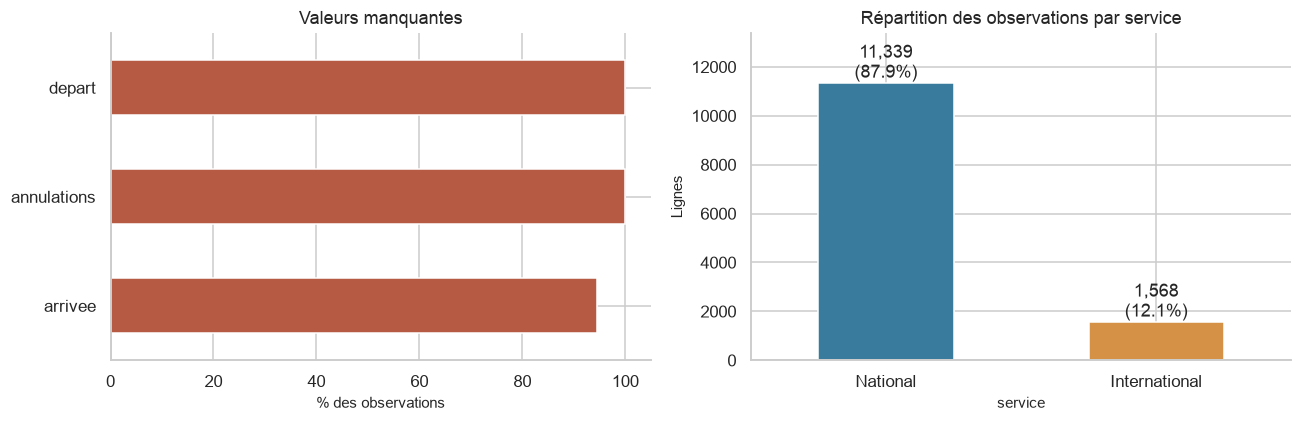

,lignes,liaisons,gares_depart,prevus_declares
service,,,,
International,1568,30,18,186439
National,11339,116,52,3342898


In [5]:
schema = pd.DataFrame({
    'Alias': [aliases[c] for c in raw.columns],
    'Type lu': raw.dtypes.astype(str),
    'Valeurs distinctes': raw.nunique(dropna=True),
    'Valeurs absentes': raw.isna().sum(), '% absent': raw.isna().mean().mul(100),
})
schema['Unité / rôle'] = [
    'mois' if a == 'date' else 'catégorie' if a in ['service', 'depart', 'arrivee']
    else 'texte' if a.startswith('comment_') else '% (0–100)' if a in CAUSES
    else 'minutes' if a in ['duree'] + MEANS else 'compteur mensuel'
    for a in schema.Alias
]
display(schema)
display(raw.head(6))
display(raw.sample(5, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
missing = schema.loc[schema['Valeurs absentes'].gt(0), '% absent'].sort_values()
missing.index = [aliases[x].replace('comment_', '') for x in missing.index]
missing.plot.barh(ax=axes[0], color='#b65a43')
axes[0].set(title='Valeurs manquantes', xlabel='% des observations', xlim=(0, 105))
service_counts = df.service.value_counts()
service_counts.plot.bar(ax=axes[1], color=['#387b9c', '#d59145'], rot=0)
axes[1].set(title='Répartition des observations par service', ylabel='Lignes')
for i, v in enumerate(service_counts):
    axes[1].text(i, v, f'{v:,}\n({v / len(df):.1%})', ha='center', va='bottom')
axes[1].set_ylim(0, service_counts.max() * 1.18)
showfig(fig)

display(df.groupby('service').agg(lignes=('service', 'size'),
                                liaisons=('liaison', 'nunique'),
                                gares_depart=('depart', 'nunique'),
                                prevus_declares=('prevus', 'sum')))

### Structure du panel et changements de périmètre

La matrice indique la présence d'une ligne, même quand le volume prévu est nul. Une absence ne signifie pas « zéro train ». Les « trous internes » sont les mois manquants **entre la première et la dernière présence d'une liaison × service**.

,service,premiere_date,derniere_date,mois_observes,volume,mois_entre_extremes,trous_internes
route_id,,,,,,,
International | LYON PART DIEU → MARSEILLE ST CHARLES,International,2025-07-01,2025-09-01,3,147,3,0
International | MARSEILLE ST CHARLES → LYON PART DIEU,International,2025-07-01,2025-09-01,3,147,3,0
International | PARIS LYON → MACON LOCHE,International,2025-07-01,2025-09-01,3,181,3,0
International | MACON LOCHE → PARIS LYON,International,2025-07-01,2025-09-01,3,190,3,0
International | CHAMBERY CHALLES LES EAUX → PARIS LYON,International,2025-07-01,2025-09-01,3,280,3,0
...,...,...,...,...,...,...,...
National | BORDEAUX ST JEAN → TOURCOING,National,2018-01-01,2026-09-01,103,2707,105,2
National | MARSEILLE ST CHARLES → TOURCOING,National,2018-01-01,2026-09-01,104,2603,105,1
International | PARIS LYON → ZURICH,International,2018-01-01,2026-09-01,104,13058,105,1


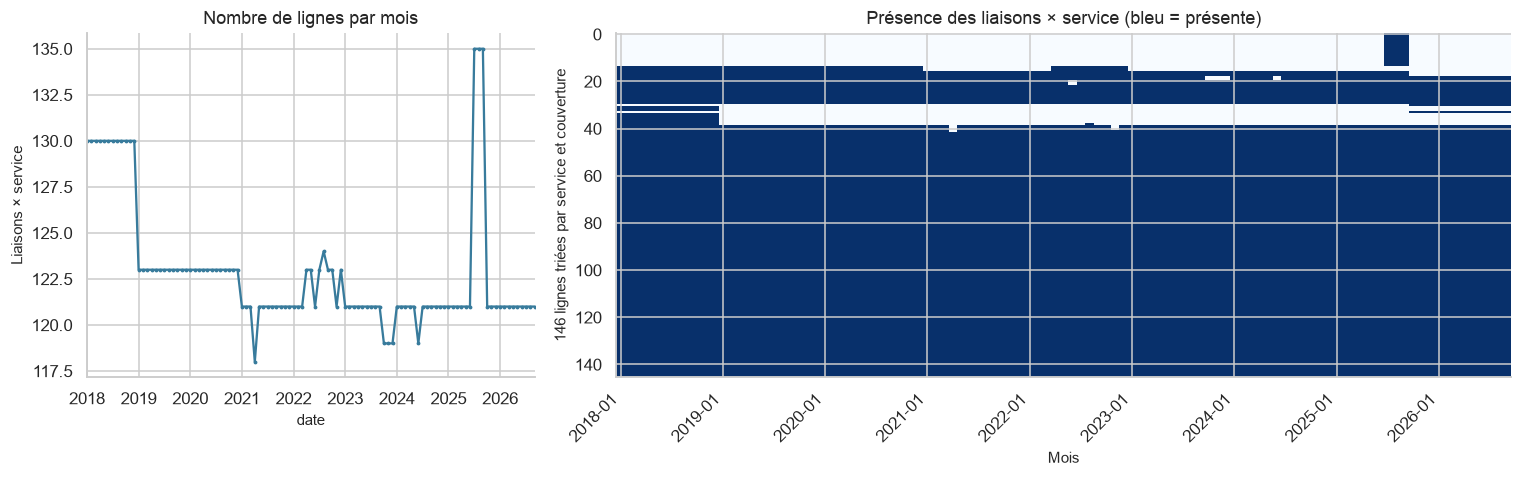

premier    dernier  \
liaison                                service                               
BARCELONA → PARIS LYON                 International 2018-01-01 2025-09-01   
                                       National      2025-10-01 2026-09-01   
BELLEGARDE (AIN) → PARIS LYON          International 2025-07-01 2025-09-01   
                                       National      2018-01-01 2026-09-01   
CHAMBERY CHALLES LES EAUX → PARIS LYON International 2025-07-01 2025-09-01   
...                                                         ...        ...   
PARIS LYON → MACON LOCHE               National      2018-01-01 2026-09-01   
PARIS LYON → MULHOUSE VILLE            International 2025-07-01 2025-09-01   
                                       National      2018-01-01 2026-09-01   
STRASBOURG → PARIS EST                 International 2025-07-01 2025-09-01   
                                       National      2018-01-01 2026-09-01   

                                                      mois  
liaison                                service              
BARCELONA → PARIS LYON                 International    93  
                                       National         12  
BELLEGARDE (AIN) → PARIS LYON          International     3  
                                       National        105  
CHAMBERY CHALLES LES EAUX → PARIS LYON International     3  
...                                                    ...  
PARIS LYON → MACON LOCHE               National        105  
PARIS LYON → MULHOUSE VILLE            International     3  
                                       National        105  
STRASBOURG → PARIS EST                 International     3  
                                       National        105  

[32 rows x 3 columns]

,date,depart,arrivee,prevus
11050,2025-07-01,LAUSANNE,PARIS LYON,118
11051,2025-07-01,PARIS LYON,LAUSANNE,120
11052,2025-07-01,PARIS LYON,MACON LOCHE,63
11053,2025-07-01,ZURICH,PARIS LYON,169
11078,2025-07-01,CHAMBERY CHALLES LES EAUX,PARIS LYON,96
11079,2025-07-01,FRANCFORT,PARIS EST,178
11080,2025-07-01,MACON LOCHE,PARIS LYON,65
11081,2025-07-01,MARSEILLE ST CHARLES,LYON PART DIEU,62
11082,2025-07-01,PARIS EST,STRASBOURG,252
11083,2025-07-01,PARIS LYON,BARCELONA,89


**À vérifier dans la source :** certaines liaisons entre gares françaises sont classées International durant juillet–septembre 2025. Paris–Barcelone change ensuite de catégorie. La variable `Service` doit être contrôlée avant une comparaison ou un modèle.

In [6]:
coverage = df.groupby('route_id').agg(service=('service', 'first'),
                                    premiere_date=('date', 'min'), derniere_date=('date', 'max'),
                                    mois_observes=('date', 'nunique'), volume=('prevus', 'sum'))
coverage['mois_entre_extremes'] = ((coverage.derniere_date.dt.year - coverage.premiere_date.dt.year) * 12
                                  + coverage.derniere_date.dt.month - coverage.premiere_date.dt.month + 1)
coverage['trous_internes'] = coverage.mois_entre_extremes - coverage.mois_observes
display(coverage.sort_values(['mois_observes', 'volume']).head(35))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 2]})
monthly.lignes.plot(ax=axes[0], color='#387b9c', marker='.', markersize=3)
axes[0].set(title='Nombre de lignes par mois', ylabel='Liaisons × service')
presence_sorted = monthly_presence.loc[coverage.sort_values(['service', 'mois_observes']).index]
axes[1].imshow(presence_sorted.values, aspect='auto', interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
ticks = np.arange(0, len(monthly_presence.columns), 12)
axes[1].set_xticks(ticks, [d.strftime('%Y-%m') for d in monthly_presence.columns[ticks]], rotation=45, ha='right')
axes[1].set(title='Présence des liaisons × service (bleu = présente)', xlabel='Mois', ylabel=f'{len(monthly_presence)} lignes triées par service et couverture')
showfig(fig)

# Changements de service à origine-destination identique.
service_changes = df.loc[df.liaison.isin(pair_service[pair_service.gt(1)].index)].groupby(
    ['liaison', 'service']).agg(premier=('date', 'min'), dernier=('date', 'max'), mois=('date', 'nunique'))
display(service_changes)
domestic_examples = df.loc[df.service.eq('International') & df.date.between('2025-07-01', '2025-09-01'),
                           ['date', 'depart', 'arrivee', 'prevus']].drop_duplicates(['depart', 'arrivee'])
display(domestic_examples)
display(Markdown('**À vérifier dans la source :** certaines liaisons entre gares françaises sont classées International durant juillet–septembre 2025. Paris–Barcelone change ensuite de catégorie. La variable `Service` doit être contrôlée avant une comparaison ou un modèle.'))

## 4. Distributions numériques

Toutes les valeurs brutes sont conservées. La statistique « IQR » signale les valeurs hors `[Q1 − 1,5 × IQR, Q3 + 1,5 × IQR]` : elle décrit des queues de distribution, **pas automatiquement des erreurs**. Les quantiles sont ceux des **lignes mensuelles**, sans pondération par les volumes.

In [7]:
stats = df[NUMERIC].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
q1, q3 = df[NUMERIC].quantile(.25), df[NUMERIC].quantile(.75)
iqr = q3 - q1
stats['% zéros'] = df[NUMERIC].eq(0).mean().mul(100)
stats['négatifs'] = df[NUMERIC].lt(0).sum()
stats['% hors IQR'] = (df[NUMERIC].lt(q1 - 1.5 * iqr) | df[NUMERIC].gt(q3 + 1.5 * iqr)).mean().mul(100)
stats['asymétrie'] = df[NUMERIC].skew()
display(stats.rename(index=LABELS))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,% zéros,négatifs,% hors IQR,asymétrie
Durée du trajet (min),"12,907.000",170.693,87.727,0.000,46.000,60.000,99.000,163.000,223.000,336.000,431.000,786.000,0.566,0,1.937,0.956
Circulations prévues,"12,907.000",273.444,184.118,0.000,14.000,33.000,151.000,231.000,365.000,617.700,868.000,"1,104.000",0.566,0,3.107,1.248
Annulations,"12,907.000",8.274,21.805,0.000,0.000,0.000,0.000,2.000,7.000,36.000,123.940,297.000,33.308,0,10.707,5.922
Trains en retard au départ,"12,907.000",86.704,88.750,0.000,0.060,5.000,22.000,52.000,127.000,273.000,383.000,598.000,1.007,0,4.354,1.624
Trains en retard à l'arrivée,"12,907.000",38.875,32.454,0.000,0.000,3.000,16.000,30.000,53.000,103.000,147.000,376.000,1.488,0,4.161,1.743
Retards > 15 min,"12,907.000",28.101,23.911,0.000,0.000,3.000,11.000,22.000,38.000,74.000,111.000,312.000,1.743,0,4.083,1.990
Retards > 30 min,"12,907.000",13.328,13.031,-44.000,0.000,0.000,4.000,10.000,18.000,38.000,59.940,202.000,6.043,43,4.649,2.306
Retards > 60 min,"12,907.000",5.491,6.388,0.000,0.000,0.000,1.000,3.000,7.000,18.000,30.000,77.000,14.217,0,6.384,2.569
Retard des trains en retard au départ (min),"12,907.000",12.598,11.585,0.000,0.117,2.168,6.432,10.696,16.231,27.596,43.362,316.188,0.992,0,3.192,8.365
Retard de tous les trains au départ (min),"12,907.000",3.218,5.017,-229.269,-0.053,0.266,1.250,2.400,4.095,8.315,14.775,115.047,0.860,170,5.005,-3.584


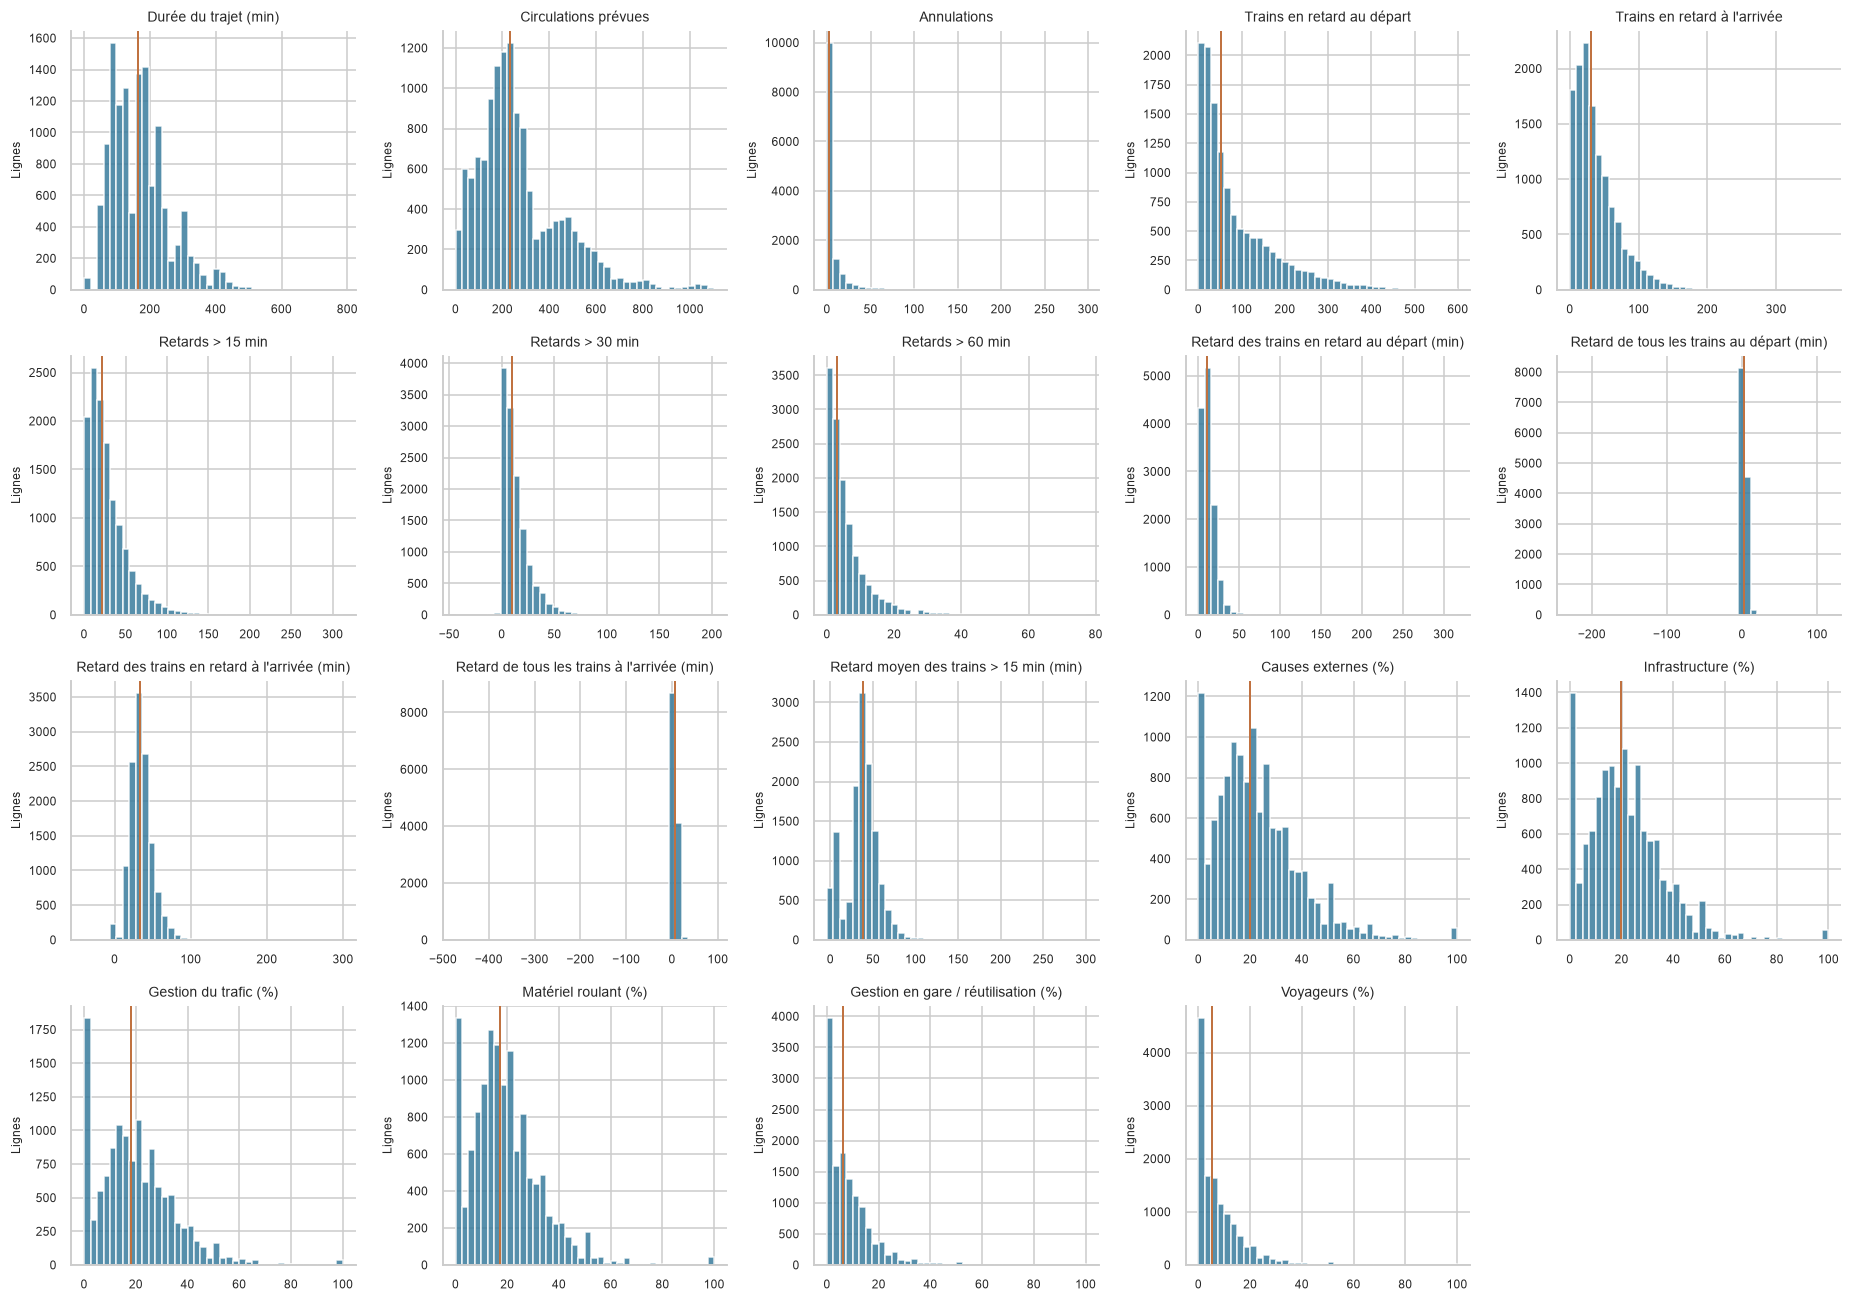

In [8]:
fig, axes = plt.subplots(4, 5, figsize=(17, 12))
for ax, col in zip(axes.flat, NUMERIC):
    ax.hist(df[col].dropna(), bins=40, color='#387b9c', alpha=.85)
    ax.axvline(df[col].median(), color='#c0713f', lw=1.3, label='Médiane')
    ax.set_title(LABELS[col], fontsize=9, wrap=True)
    ax.set_ylabel('Lignes', fontsize=8)
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(NUMERIC):]:
    ax.set_visible(False)
showfig(fig)

### Volumes, durées et retards selon le service

L'échelle logarithmique des compteurs utilise `log1p(x)`, défini ici seulement pour les compteurs non négatifs. Les valeurs négatives restent disponibles dans l'audit. Les boxplots des moyennes brutes montrent également les valeurs extrêmes négatives.

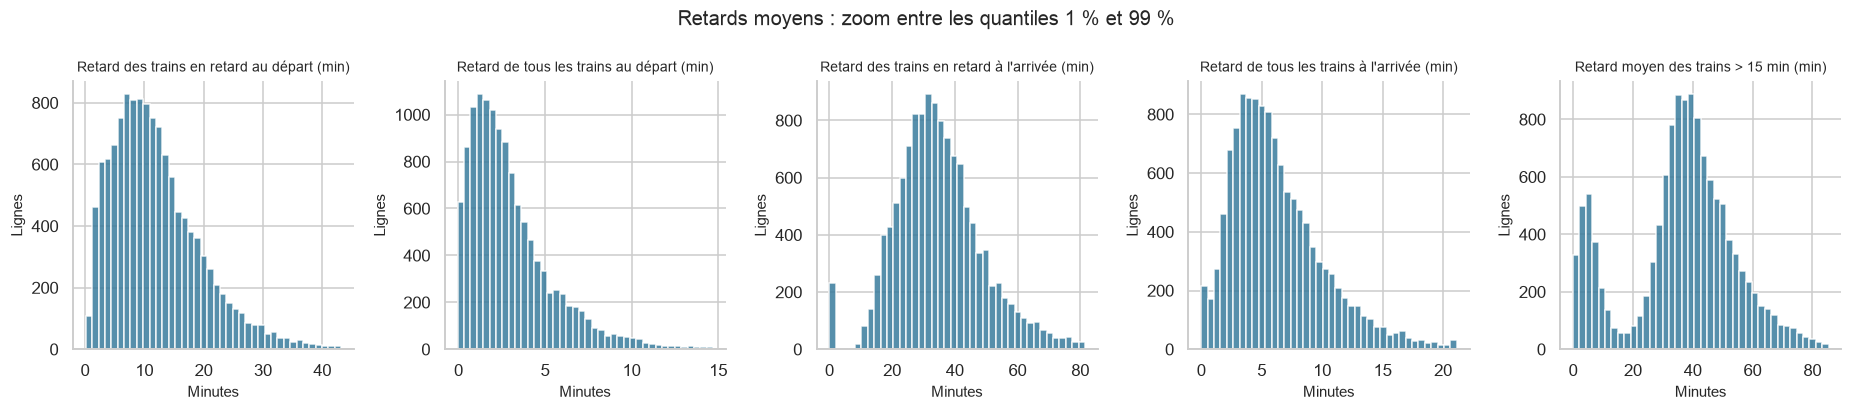

,Borne 1 %,Borne 99 %,Lignes hors fenêtre
Variable,,,
moy_retard_dep,0.117,43.362,259
moy_tous_dep,-0.053,14.775,260
moy_retard_arr,0.000,81.560,132
moy_tous_arr,0.000,21.140,252
moy15,0.000,85.433,138


In [9]:
# Zoom graphique uniquement : les queues restent dans les statistiques et l'audit.
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
zoom_limits = []
for ax, col in zip(axes, MEANS):
    lo, hi = df[col].quantile([.01, .99])
    in_window = df[col].between(lo, hi)
    ax.hist(df.loc[in_window, col], bins=40, color='#387b9c', alpha=.85)
    ax.set(title=LABELS[col], xlabel='Minutes', ylabel='Lignes')
    ax.title.set_fontsize(9)
    ax.title.set_wrap(True)
    zoom_limits.append({'Variable': col, 'Borne 1 %': lo, 'Borne 99 %': hi,
                        'Lignes hors fenêtre': int((~in_window).sum())})
fig.suptitle('Retards moyens : zoom entre les quantiles 1 % et 99 %', fontsize=13)
showfig(fig)
display(pd.DataFrame(zoom_limits).set_index('Variable'))

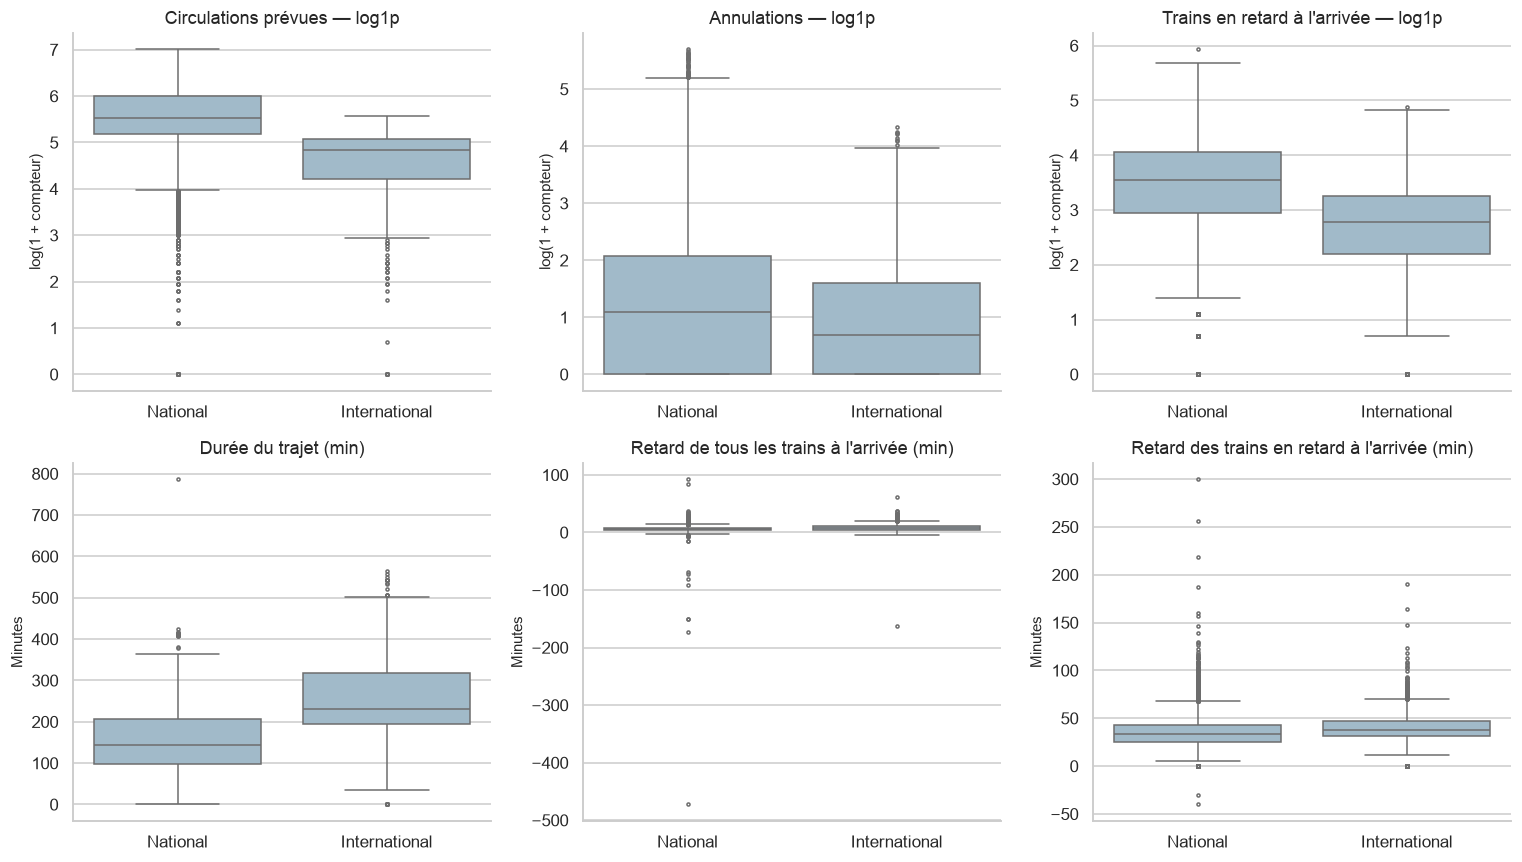

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
taux_annulation,"12,834.000",3.692,8.356,0.000,0.000,0.000,0.693,2.941,20.526,42.105,92.683
taux_dep,"12,833.000",33.112,25.226,0.000,2.524,12.445,23.932,50.000,83.699,95.348,100.000
taux_arr,"12,834.000",14.926,8.440,0.000,1.184,9.375,13.360,18.698,29.735,42.857,100.000
taux15,"12,832.000",11.449,7.796,0.000,0.000,6.262,9.615,14.655,25.351,39.044,100.000
taux30,"12,791.000",5.480,4.665,0.000,0.000,2.521,4.444,7.292,13.528,21.034,100.000
taux60,"12,834.000",2.221,2.599,0.000,0.000,0.671,1.630,3.117,6.452,10.063,100.000


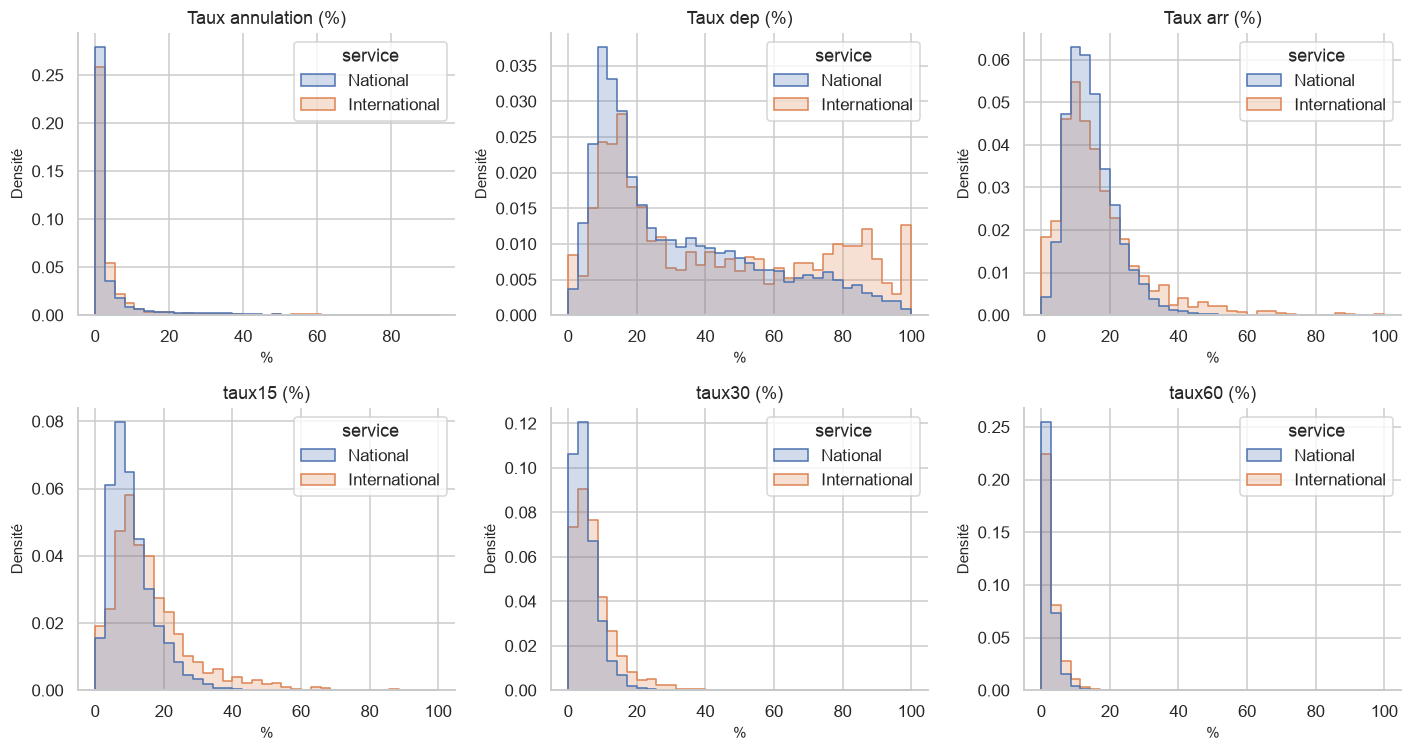

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat[:3], ['prevus', 'annules', 'retard_arr']):
    plot_data = df.loc[df[col].ge(0), ['service', col]].copy()
    plot_data['log1p'] = np.log1p(plot_data[col])
    sns.boxplot(data=plot_data, x='service', y='log1p', ax=ax, color='#9bbccf', fliersize=2)
    ax.set(title=LABELS[col] + ' — log1p', xlabel='', ylabel='log(1 + compteur)')
for ax, col in zip(axes.flat[3:], ['duree', 'moy_tous_arr', 'moy_retard_arr']):
    sns.boxplot(data=df, x='service', y=col, ax=ax, color='#9bbccf', fliersize=2)
    ax.set(title=LABELS[col], xlabel='', ylabel='Minutes')
showfig(fig)

rate_cols = ['taux_annulation', 'taux_dep', 'taux_arr', 'taux15', 'taux30', 'taux60']
display(df[rate_cols].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, rate_cols):
    sns.histplot(data=df, x=col, hue='service', bins=35, ax=ax, element='step',
                 stat='density', common_norm=False)
    ax.set(title=col.replace('taux_', 'Taux ') + ' (%)', xlabel='%', ylabel='Densité')
showfig(fig)

## 5. Qualité et particularités à investiguer

Les contrôles peuvent se recouvrir : leurs effectifs ne doivent pas être additionnés. Une petite moyenne négative sur **tous les trains** peut refléter des arrivées ou départs en avance. Une moyenne négative sur **les seuls trains en retard**, des compteurs négatifs ou une moyenne très fortement négative appellent une vérification. Le seuil exploratoire de −30 min sert uniquement à repérer les cas extrêmes.

Les comparaisons avec « réalisés estimés » reposent sur `prévus − annulés`. Les contraintes entre `> 15 min` et d'autres compteurs sont marquées « périmètre à vérifier », compte tenu du qualificatif lié aux vols dans le schéma. La contrainte `> 60 min ≤ > 30 min` est attendue pour des compteurs cumulés de même population.

,Lignes,% des lignes
Compteur négatif,43,0.333
Annulés > prévus,63,0.488
Départs en retard > réalisés estimés,64,0.496
Arrivées en retard > réalisés estimés,63,0.488
> 60 min > > 30 min,354,2.743
> 30 min > > 15 min (périmètre à vérifier),3,0.023
> 15 min > retards arrivée (périmètre à vérifier),31,0.240
Durée nulle,73,0.566
Prévisions nulles,73,0.566
Réalisés estimés ≤ 0,73,0.566


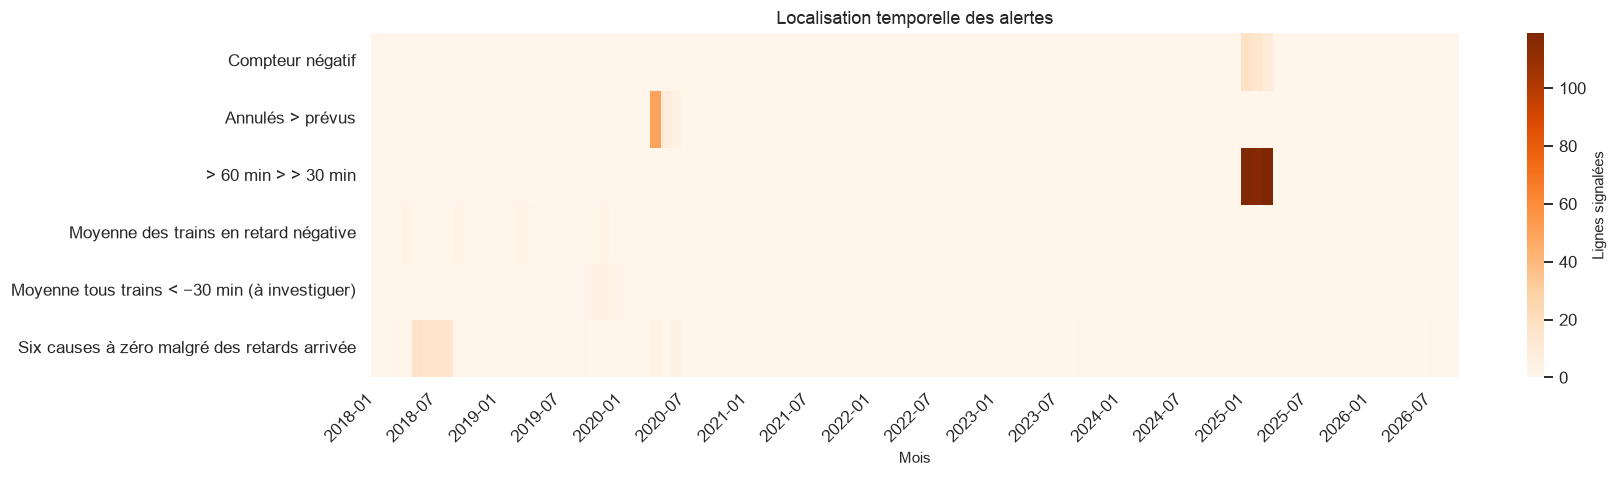

Compteurs négatifs : exemples


,date,service,depart,arrivee,prevus,annules,retard_dep,retard_arr,n15,n30,n60
10326,2025-01-01,International,LAUSANNE,PARIS LYON,172,10,83,15,15,-4,9
10329,2025-01-01,National,DIJON VILLE,PARIS LYON,426,4,177,60,47,-1,30
10330,2025-01-01,National,DOUAI,PARIS NORD,167,2,60,43,21,-1,9
10357,2025-01-01,National,LE MANS,PARIS MONTPARNASSE,472,5,242,123,51,-1,30
10358,2025-01-01,National,MARSEILLE ST CHARLES,MARNE LA VALLEE,296,0,37,43,43,-2,17
10379,2025-01-01,National,LILLE,PARIS NORD,643,4,136,130,49,-1,18
10380,2025-01-01,National,LYON PART DIEU,LILLE,352,0,249,75,64,-44,21
10381,2025-01-01,National,LYON PART DIEU,MARNE LA VALLEE,360,0,255,70,42,-2,18
10382,2025-01-01,National,LYON PART DIEU,PARIS LYON,732,3,242,64,43,-3,17
10392,2025-01-01,National,QUIMPER,PARIS MONTPARNASSE,281,34,11,31,31,-1,14


Moyennes tous trains les plus négatives à l’arrivée


,date,service,depart,arrivee,duree,prevus,annules,moy_retard_dep,moy_tous_dep,moy_retard_arr,moy_tous_arr,moy15
2998,2019-12-01,National,STRASBOURG,NANTES,786,10,4,1.244,1.244,0.000,-472.639,0.000
2985,2019-12-01,National,LYON PART DIEU,MONTPELLIER,300,75,20,14.599,10.288,35.881,-173.077,44.239
3253,2020-02-01,International,PARIS EST,FRANCFORT,346,165,7,7.518,-12.982,31.472,-163.042,57.084
2877,2019-11-01,National,NIMES,PARIS LYON,224,226,11,8.766,-112.262,-40.109,-151.291,34.677
2824,2019-11-01,National,MONTPELLIER,PARIS LYON,380,227,11,4.910,4.277,-30.512,-150.562,34.677
2758,2019-10-01,National,NIMES,PARIS LYON,182,266,12,11.038,-92.768,17.234,-90.631,46.836
2781,2019-10-01,National,MONTPELLIER,PARIS LYON,308,263,12,7.736,7.013,45.921,-80.855,45.921
2829,2019-11-01,National,VALENCE ALIXAN TGV,PARIS LYON,135,233,11,9.356,-69.838,27.173,-71.529,33.846


Annulations supérieures au volume prévu : exemples


,date,service,depart,arrivee,duree,prevus,annules,realises
3406,2020-04-01,National,PARIS MONTPARNASSE,ST MALO,0,0,8,-8
3407,2020-04-01,National,PARIS MONTPARNASSE,TOURS,0,0,9,-9
3409,2020-04-01,National,NANTES,STRASBOURG,0,0,2,-2
3411,2020-04-01,National,PARIS NORD,DOUAI,0,0,12,-12
3412,2020-04-01,National,DUNKERQUE,PARIS NORD,0,0,15,-15
3414,2020-04-01,National,MARSEILLE ST CHARLES,TOURCOING,0,0,1,-1
3415,2020-04-01,National,LYON PART DIEU,MARNE LA VALLEE,0,0,19,-19
3416,2020-04-01,National,MARNE LA VALLEE,MARSEILLE ST CHARLES,0,0,14,-14
3417,2020-04-01,National,MARSEILLE ST CHARLES,MARNE LA VALLEE,0,0,13,-13
3418,2020-04-01,National,PARIS LYON,AIX EN PROVENCE TGV,0,0,17,-17


In [11]:
display(audit_summary)
focus_checks = ['Compteur négatif', 'Annulés > prévus', '> 60 min > > 30 min',
                'Moyenne des trains en retard négative', 'Moyenne tous trains < −30 min (à investiguer)',
                'Six causes à zéro malgré des retards arrivée']
quality_month = audit[focus_checks].groupby(df.date).sum()
fig, ax = plt.subplots(figsize=(16, 4.5))
ticks = np.arange(0, len(quality_month), 6)
sns.heatmap(quality_month.T, cmap='Oranges', ax=ax, cbar_kws={'label': 'Lignes signalées'},
            xticklabels=False, yticklabels=True)
ax.set_xticks(ticks + .5, [x.strftime('%Y-%m') for x in quality_month.index[ticks]], rotation=45, ha='right')
ax.set(xlabel='Mois', ylabel='', title='Localisation temporelle des alertes')
showfig(fig)

print('Compteurs négatifs : exemples')
display(df.loc[audit['Compteur négatif'], KEY + COUNTS].head(15))
print('Moyennes tous trains les plus négatives à l’arrivée')
display(df.nsmallest(8, 'moy_tous_arr')[KEY + ['duree', 'prevus', 'annules'] + MEANS])
print('Annulations supérieures au volume prévu : exemples')
display(df.loc[audit['Annulés > prévus'], KEY + ['duree', 'prevus', 'annules', 'realises']].head(12))

### Rupture des compteurs > 30 minutes et de la moyenne > 15 minutes

Une colonne peut être complète sans être fiable. Les figures suivantes isolent deux changements de comportement. L'hypothèse d'une erreur de publication ou d'une modification de définition reste à confirmer auprès de la source ; aucune valeur n'est reconstituée.

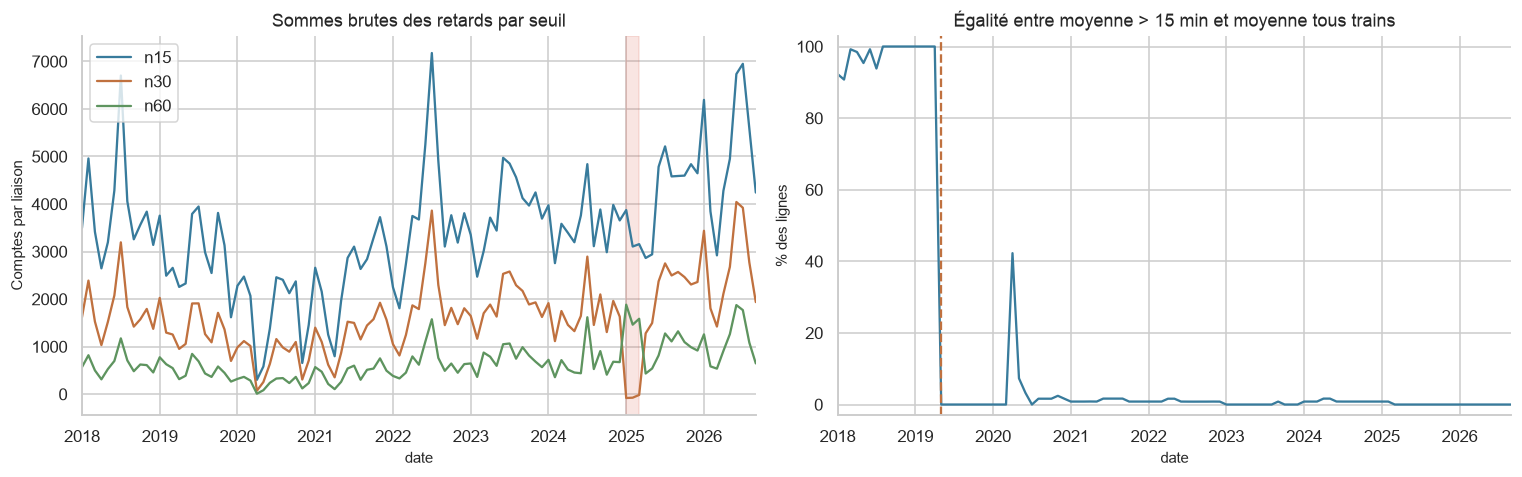

,n15,n30,n60
date,,,
2024-11-01,3982,1962,682
2024-12-01,3655,1631,674
2025-01-01,3873,-81,1882
2025-02-01,3106,-74,1462
2025-03-01,3156,-16,1586
2025-04-01,2865,1280,434
2025-05-01,2942,1496,540


,% moyennes identiques
date,
2018-01-01,92.308
2018-02-01,90.769
2018-03-01,99.231
2018-04-01,98.462
2018-05-01,95.385
2018-06-01,99.231
2018-07-01,93.846
2018-08-01,100.000
2018-09-01,100.000


Exemples de compteurs > 60 min supérieurs à > 30 min


,date,service,depart,arrivee,n15,n30,n60
10324,2025-01-01,International,FRANCFORT,PARIS EST,27,0,18
10325,2025-01-01,International,GENEVE,PARIS LYON,19,0,13
10326,2025-01-01,International,LAUSANNE,PARIS LYON,15,-4,9
10327,2025-01-01,International,ZURICH,PARIS LYON,18,0,10
10328,2025-01-01,National,ANGOULEME,PARIS MONTPARNASSE,28,0,10
10329,2025-01-01,National,DIJON VILLE,PARIS LYON,47,-1,30
10330,2025-01-01,National,DOUAI,PARIS NORD,21,-1,9
10331,2025-01-01,National,DUNKERQUE,PARIS NORD,22,0,8
10332,2025-01-01,National,GRENOBLE,PARIS LYON,27,0,12
10333,2025-01-01,National,LAVAL,PARIS MONTPARNASSE,18,0,10


435 lignes dans review_rows ; données originales conservées dans raw et df.


In [12]:
threshold_month = df.groupby('date')[['n15', 'n30', 'n60']].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
threshold_month.plot(ax=axes[0], color=['#387b9c', '#c0713f', '#5e945f'])
axes[0].set(title='Sommes brutes des retards par seuil', ylabel='Comptes par liaison')
axes[0].axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-03-31'), color='#d9513e', alpha=.15)
same_by_month = audit['Moyenne > 15 égale à moyenne tous trains'].groupby(df.date).mean().mul(100)
same_by_month.plot(ax=axes[1], color='#387b9c')
axes[1].set(title='Égalité entre moyenne > 15 min et moyenne tous trains', ylabel='% des lignes', ylim=(-3, 103))
axes[1].axvline(pd.Timestamp('2019-05-01'), color='#c0713f', linestyle='--')
showfig(fig)
display(threshold_month.loc['2024-11':'2025-05'])
display(pd.DataFrame({'% moyennes identiques': same_by_month}).loc['2018-01':'2019-07'])
print('Exemples de compteurs > 60 min supérieurs à > 30 min')
display(df.loc[audit['> 60 min > > 30 min'], KEY + ['n15', 'n30', 'n60']].head(10))

# Catalogue des lignes à examiner, accessible pour des filtres complémentaires.
hard_checks = ['Compteur négatif', 'Annulés > prévus', '> 60 min > > 30 min',
               'Moyenne des trains en retard négative', 'Moyenne tous trains < −30 min (à investiguer)']
review_rows = df.loc[audit[hard_checks].any(axis=1)].copy()
review_rows['alertes'] = audit.loc[review_rows.index, hard_checks].apply(
    lambda row: '; '.join(row.index[row]), axis=1)
print(f'{len(review_rows):,} lignes dans review_rows ; données originales conservées dans raw et df.')

## 6. Évolution temporelle et saisonnalité

Les taux sont des **ratios de sommes sur les mêmes lignes valides**. Ils n'utilisent pas la moyenne simple des taux de liaison. Les nombres de lignes retenues et les dénominateurs sont affichés pour rendre le filtrage visible. Un compteur `> 30 min` peut rester dans [0, réalisés] tout en violant `> 60 min ≤ > 30 min` : la série correspondante sera comparée à une version qui exclut aussi cette incohérence.

,mois_observes,lignes,prevus_declares,taux_annulation,taux_arr,lignes_annulation,lignes_arr,denom_annulation,denom_arr
annee,,,,,,,,,
2018,12,1560,414653,7.621,17.804,1560,1560,414653,383053
2019,12,1476,378790,2.628,13.831,1476,1476,378790,368835
2020,12,1476,263853,5.029,12.403,1403,1403,263853,250584
2021,12,1449,383087,4.312,11.278,1449,1449,383087,366568
2022,12,1467,437705,1.568,14.330,1467,1467,437705,430843
2023,12,1446,445544,3.475,14.677,1446,1446,445544,430062
2024,12,1450,444878,1.098,13.686,1450,1450,444878,439992
2025,12,1494,437974,0.765,15.050,1494,1494,437974,434624
2026,9,1089,322853,1.357,18.726,1089,1089,322853,318473


2026 : période partielle ; comparer les mêmes mois, pas les volumes annuels entiers.


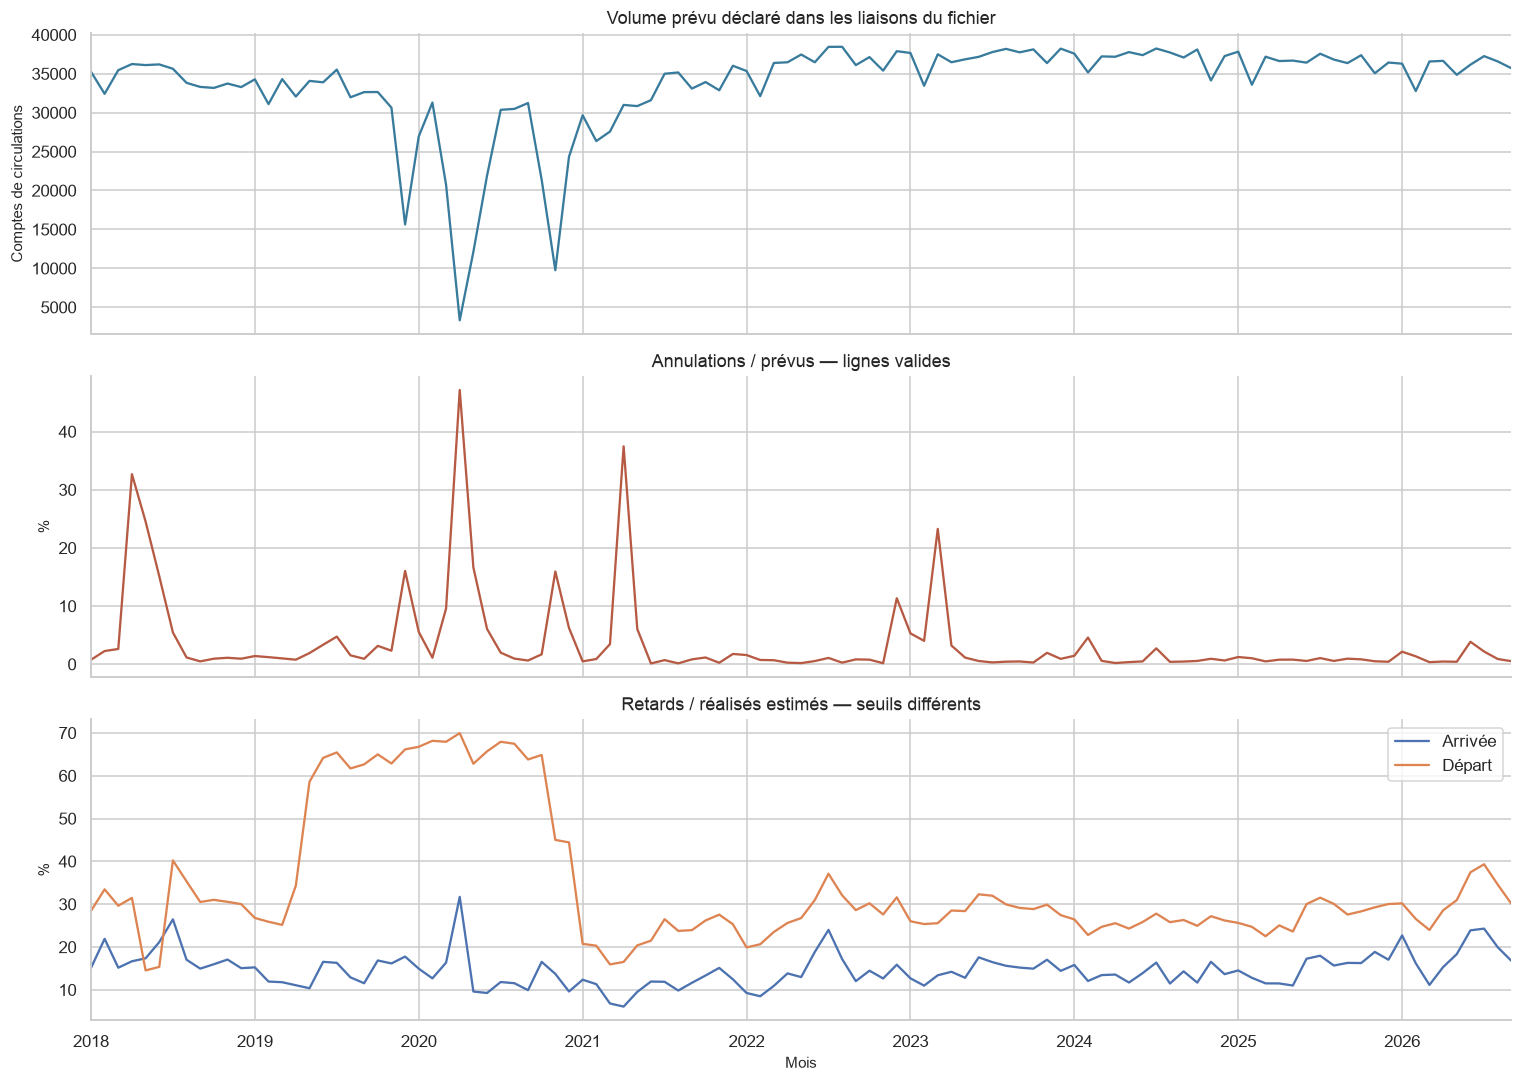

Mois ayant les taux d’annulation les plus élevés dans le fichier


,prevus_declares,taux_annulation,lignes,lignes_annulation,denom_annulation
date,,,,,
2020-04-01,3325,47.158,123,73,3325
2021-04-01,30993,37.463,118,118,30993
2018-04-01,36243,32.671,130,130,36243
2018-05-01,36111,24.535,130,130,36111
2023-03-01,37496,23.264,121,121,37496
2020-05-01,12129,16.638,123,114,12129
2019-12-01,15633,16.043,123,123,15633
2020-11-01,9757,15.937,123,121,9757


In [13]:
annual = aggregate_rates(df, 'annee')
annual['mois_observes'] = df.groupby('annee').date.nunique()
display(annual[['mois_observes', 'lignes', 'prevus_declares', 'taux_annulation', 'taux_arr',
                'lignes_annulation', 'lignes_arr', 'denom_annulation', 'denom_arr']])
print('2026 : période partielle ; comparer les mêmes mois, pas les volumes annuels entiers.')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
monthly.prevus_declares.plot(ax=axes[0], color='#387b9c')
axes[0].set(title='Volume prévu déclaré dans les liaisons du fichier', ylabel='Comptes de circulations')
monthly.taux_annulation.plot(ax=axes[1], color='#b65a43')
axes[1].set(title='Annulations / prévus — lignes valides', ylabel='%')
monthly[['taux_arr', 'taux_dep']].rename(columns={'taux_arr': 'Arrivée', 'taux_dep': 'Départ'}).plot(ax=axes[2])
axes[2].set(title='Retards / réalisés estimés — seuils différents', ylabel='%', xlabel='Mois')
showfig(fig)

print('Mois ayant les taux d’annulation les plus élevés dans le fichier')
display(monthly.nlargest(8, 'taux_annulation')[['prevus_declares', 'taux_annulation',
                                               'lignes', 'lignes_annulation', 'denom_annulation']])

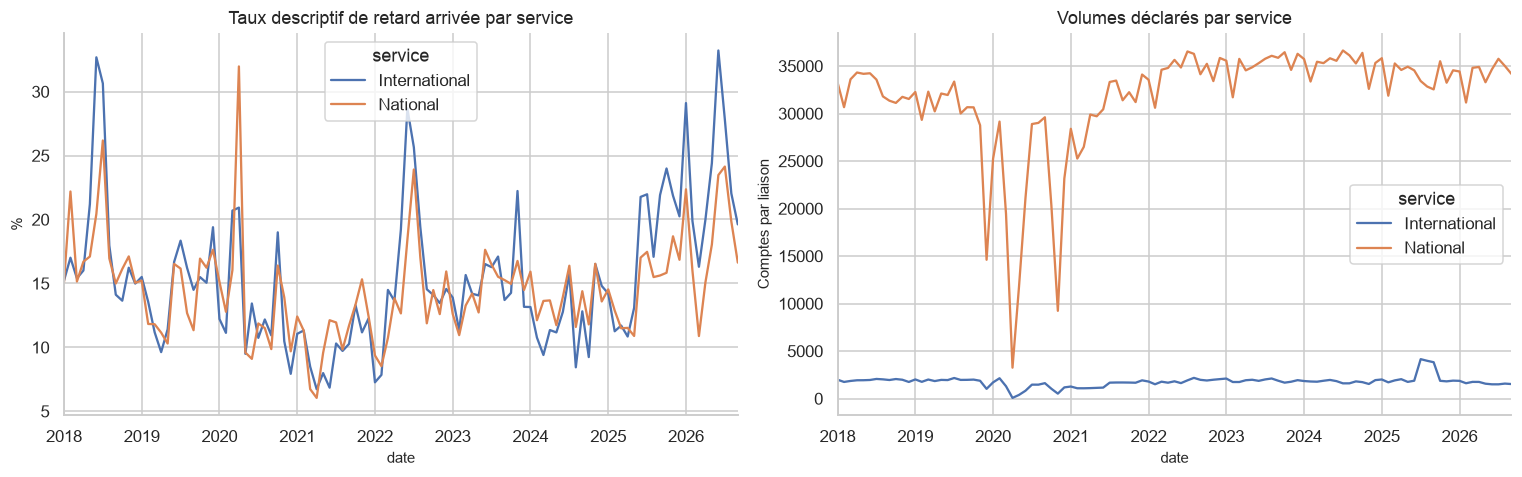

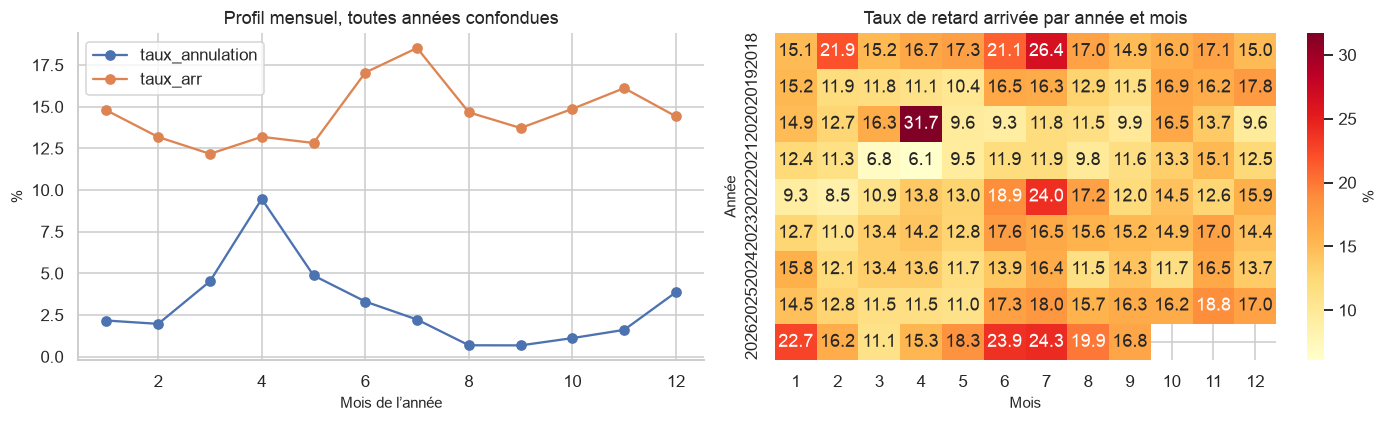

Le profil mensuel mélange tendances, changements de périmètre et mois exceptionnels. Il décrit la saisonnalité apparente, sans identifier un effet causal du mois. Les cases non observées de 2026 restent vides.

In [14]:
by_service_month = aggregate_rates(df, ['date', 'service'])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_service_month.taux_arr.unstack('service').plot(ax=axes[0])
axes[0].set(title='Taux descriptif de retard arrivée par service', ylabel='%')
by_service_month.prevus_declares.unstack('service').plot(ax=axes[1])
axes[1].set(title='Volumes déclarés par service', ylabel='Comptes par liaison')
showfig(fig)

season = aggregate_rates(df, 'mois')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
season[['taux_annulation', 'taux_arr']].plot(ax=axes[0], marker='o')
axes[0].set(title='Profil mensuel, toutes années confondues', xlabel='Mois de l’année', ylabel='%')
year_month = monthly.assign(annee=monthly.index.year, mois=monthly.index.month).pivot(
    index='annee', columns='mois', values='taux_arr')
sns.heatmap(year_month, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': '%'})
axes[1].set(title='Taux de retard arrivée par année et mois', xlabel='Mois', ylabel='Année')
showfig(fig)
display(Markdown('Le profil mensuel mélange tendances, changements de périmètre et mois exceptionnels. Il décrit la saisonnalité apparente, sans identifier un effet causal du mois. Les cases non observées de 2026 restent vides.'))

### Sensibilité aux lignes incohérentes et au périmètre

Le panel constant conserve uniquement les liaisons × service présentes **tous les mois**. La comparaison par année sur janvier–septembre évite de confronter les neuf mois de 2026 à douze mois pour les autres années. Pour `> 30 min`, la version stricte ajoute les contraintes de compteurs cumulés.

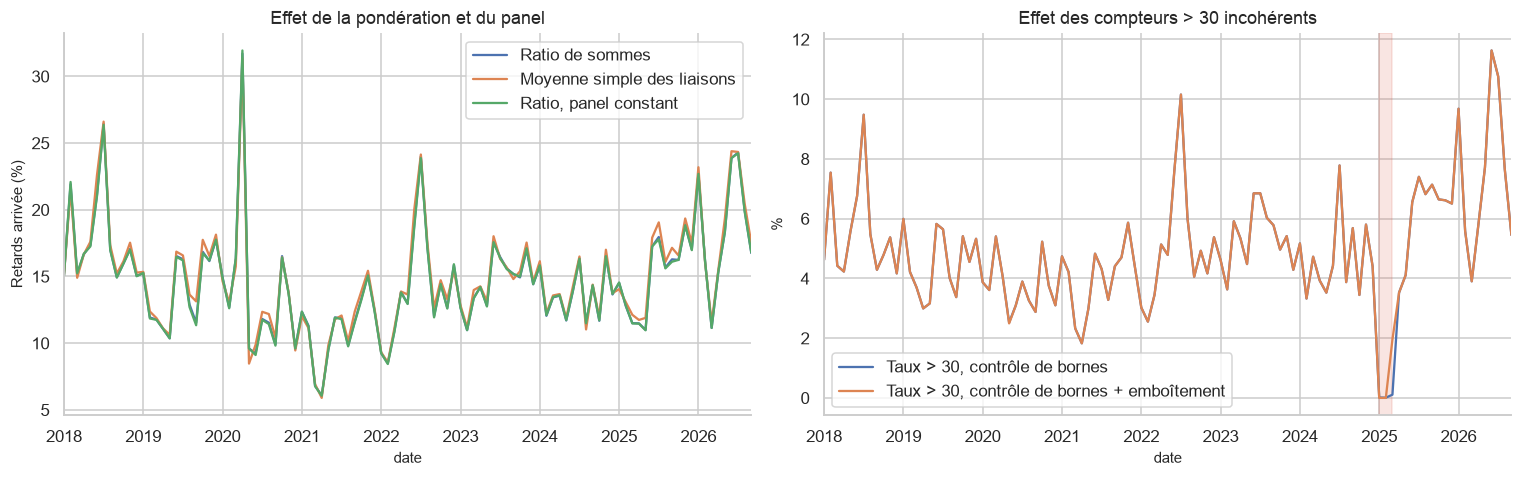

,lignes,prevus_declares,taux_annulation,taux_arr
annee,,,,
2018,1170,314457,9.731,18.423
2019,1107,299869,1.903,13.094
2020,1107,208397,4.719,12.234
2021,1086,280262,5.500,10.385
2022,1100,327276,0.676,14.340
2023,1089,332826,4.300,14.414
2024,1087,335366,1.228,13.629
2025,1131,329102,0.823,14.290
2026,1089,322853,1.357,18.726


,lignes_total,lignes_30_bornes,lignes_30_strict
date,,,
2024-12-01,121,121,121
2025-01-01,121,103,3
2025-02-01,121,106,4
2025-03-01,121,111,1
2025-04-01,121,121,121


In [15]:
balanced_ids = monthly_presence.index[monthly_presence.all(axis=1)]
balanced_monthly = aggregate_rates(df.loc[df.route_id.isin(balanced_ids)], 'date')
naive_arr = df.groupby('date').taux_arr.mean()
strict30 = df.valid_taux30 & df.n30.ge(df.n60) & df.n30.le(df.n15)
sums30 = df.loc[strict30].groupby('date')[['n30', 'realises']].sum()
strict_rate30 = 100 * sums30.n30 / sums30.realises.where(sums30.realises.gt(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
pd.DataFrame({'Ratio de sommes': monthly.taux_arr,
              'Moyenne simple des liaisons': naive_arr,
              'Ratio, panel constant': balanced_monthly.taux_arr}).plot(ax=axes[0])
axes[0].set(title='Effet de la pondération et du panel', ylabel='Retards arrivée (%)')
pd.DataFrame({'Taux > 30, contrôle de bornes': monthly.taux_30,
              'Taux > 30, contrôle de bornes + emboîtement': strict_rate30}).plot(ax=axes[1])
axes[1].axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-03-31'), color='#d9513e', alpha=.15)
axes[1].set(title='Effet des compteurs > 30 incohérents', ylabel='%')
showfig(fig)
display(aggregate_rates(df.loc[df.mois.le(9)], 'annee')[
    ['lignes', 'prevus_declares', 'taux_annulation', 'taux_arr']])
display(pd.DataFrame({'lignes_total': df.groupby('date').size(),
                      'lignes_30_bornes': df.loc[df.valid_taux30].groupby('date').size(),
                      'lignes_30_strict': df.loc[strict30].groupby('date').size()}).loc['2024-12':'2025-04'])

## 7. Liaisons, gares et asymétrie des sens

Les classements portent sur les **12 derniers mois disponibles** avec au moins 9 mois et 500 circulations réalisées estimées valides pour le retard à l'arrivée. Ces seuils exploratoires sont modifiables. Les volumes évitent de mettre en tête une liaison sur la base de quelques observations.

Fenêtre : 2025-10 à 2026-09
118 liaisons × service éligibles


,mois_observes,mois_arr_valides,denom_arr,taux_arr,taux_annulation
route_id,,,,,
International | PARIS EST → STUTTGART,12,12,1520,58.355,3.185
International | ITALIE → PARIS LYON,12,12,906,36.865,0.875
National | MACON LOCHE → PARIS LYON,12,12,2690,33.866,0.628
International | PARIS EST → FRANCFORT,12,12,2259,33.378,3.047
National | CHAMBERY CHALLES LES EAUX → PARIS LYON,12,12,3061,32.604,0.455
National | LYON PART DIEU → MARNE LA VALLEE,12,12,4228,31.741,0.798
National | DOUAI → PARIS NORD,12,12,1852,28.024,3.542
National | LYON PART DIEU → MARSEILLE ST CHARLES,12,12,5785,27.779,0.584
National | ARRAS → PARIS NORD,12,12,5329,27.641,3.091


,mois_observes,denom_arr,taux_arr,taux_annulation
route_id,,,,
International | ZURICH → PARIS LYON,12,1489,8.261,0.931
National | PARIS MONTPARNASSE → ST MALO,12,1283,10.133,1.232
International | LAUSANNE → PARIS LYON,12,1163,10.146,1.441
National | PARIS MONTPARNASSE → BREST,12,3209,10.408,1.985
National | BREST → PARIS MONTPARNASSE,12,3279,10.461,2.178
National | PARIS EST → REIMS,12,2648,10.536,0.113
National | REIMS → PARIS EST,12,2598,11.124,0.269
National | PARIS LYON → LYON PART DIEU,12,7513,11.527,0.345
National | QUIMPER → PARIS MONTPARNASSE,12,3172,12.201,1.856


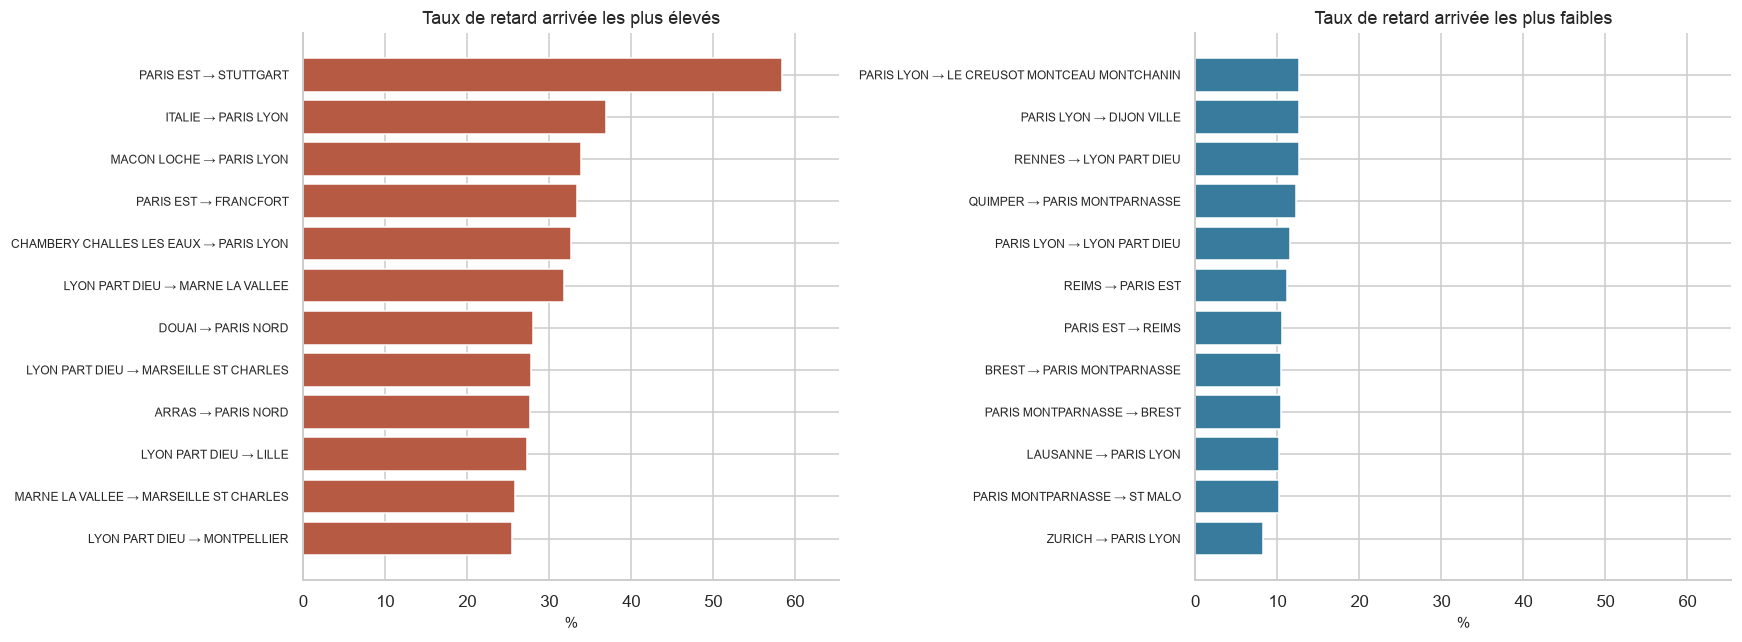

In [16]:
WINDOW_MONTHS = 12
MIN_MONTHS = 9
MIN_TRAINS = 500
start_recent = df.date.max() - pd.DateOffset(months=WINDOW_MONTHS - 1)
recent = df.loc[df.date.ge(start_recent)].copy()
routes_recent = aggregate_rates(recent, 'route_id')
routes_recent['mois_observes'] = recent.groupby('route_id').date.nunique()
routes_recent['mois_arr_valides'] = recent.loc[recent.valid_taux_arr].groupby('route_id').date.nunique()
ranked = routes_recent.loc[routes_recent.mois_arr_valides.ge(MIN_MONTHS)
                            & routes_recent.denom_arr.ge(MIN_TRAINS)]
print('Fenêtre :', start_recent.strftime('%Y-%m'), 'à', df.date.max().strftime('%Y-%m'))
print(f'{len(ranked)} liaisons × service éligibles')
display(ranked.nlargest(12, 'taux_arr')[['mois_observes', 'mois_arr_valides', 'denom_arr', 'taux_arr', 'taux_annulation']])
display(ranked.nsmallest(12, 'taux_arr')[['mois_observes', 'denom_arr', 'taux_arr', 'taux_annulation']])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
worst = ranked.nlargest(12, 'taux_arr').sort_values('taux_arr')
best = ranked.nsmallest(12, 'taux_arr').sort_values('taux_arr')
for ax, data, title, color in [(axes[0], worst, 'Taux de retard arrivée les plus élevés', '#b65a43'),
                               (axes[1], best, 'Taux de retard arrivée les plus faibles', '#387b9c')]:
    ax.barh([s.split(' | ', 1)[-1] for s in data.index], data.taux_arr, color=color)
    ax.set(title=title, xlabel='%', xlim=(0, max(25, worst.taux_arr.max() * 1.12)))
    ax.tick_params(axis='y', labelsize=8)
showfig(fig)

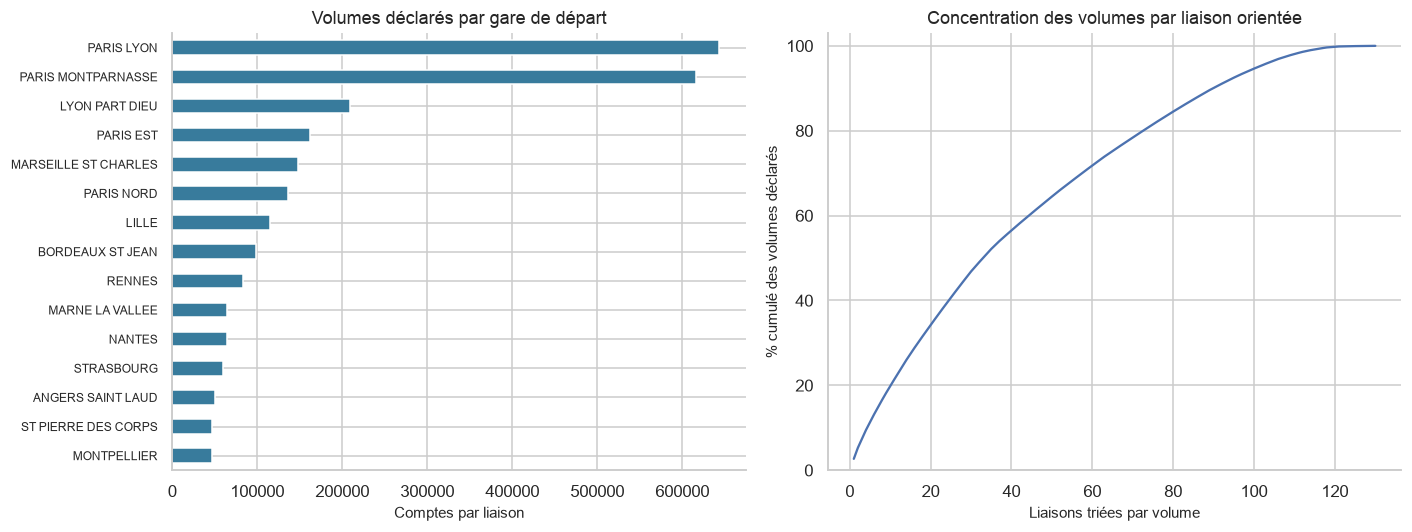

Les 10 premières liaisons représentent 19.8% des volumes prévus déclarés.


mois_communs  \
service       depart_aller              arrivee_aller                        
International PARIS EST                 STUTTGART                       12   
National      MACON LOCHE               PARIS LYON                      12   
International ITALIE                    PARIS LYON                      12   
National      LYON PART DIEU            MARSEILLE ST CHARLES            12   
                                        MARNE LA VALLEE                 12   
              LILLE                     LYON PART DIEU                  12   
              PARIS EST                 STRASBOURG                      12   
              LE MANS                   PARIS MONTPARNASSE              12   
International FRANCFORT                 PARIS EST                       12   
National      ARRAS                     PARIS NORD                      12   
              PARIS MONTPARNASSE        POITIERS                        12   
              CHAMBERY CHALLES LES EAUX PARIS LYON                      12   

                                                              volume_aller  \
service       depart_aller              arrivee_aller                        
International PARIS EST                 STUTTGART                     1520   
National      MACON LOCHE               PARIS LYON                    2690   
International ITALIE                    PARIS LYON                     906   
National      LYON PART DIEU            MARSEILLE ST CHARLES          5785   
                                        MARNE LA VALLEE               4228   
              LILLE                     LYON PART DIEU                4402   
              PARIS EST                 STRASBOURG                    7658   
              LE MANS                   PARIS MONTPARNASSE            5073   
International FRANCFORT                 PARIS EST                     2197   
National      ARRAS                     PARIS NORD                    5329   
              PARIS MONTPARNASSE        POITIERS                      6742   
              CHAMBERY CHALLES LES EAUX PARIS LYON                    3061   

                                                              volume_retour  \
service       depart_aller              arrivee_aller                         
International PARIS EST                 STUTTGART                      1530   
National      MACON LOCHE               PARIS LYON                     3020   
International ITALIE                    PARIS LYON                      913   
National      LYON PART DIEU            MARSEILLE ST CHARLES           5921   
                                        MARNE LA VALLEE                4783   
              LILLE                     LYON PART DIEU                 4100   
              PARIS EST                 STRASBOURG                     7372   
              LE MANS                   PARIS MONTPARNASSE             5385   
International FRANCFORT                 PARIS EST                      2259   
National      ARRAS                     PARIS NORD                     5555   
              PARIS MONTPARNASSE        POITIERS                       5146   
              CHAMBERY CHALLES LES EAUX PARIS LYON                     3094   

                                                              taux_aller  \
service       depart_aller              arrivee_aller                      
International PARIS EST                 STUTTGART                 58.355   
National      MACON LOCHE               PARIS LYON                33.866   
International ITALIE                    PARIS LYON                36.865   
National      LYON PART DIEU            MARSEILLE ST CHARLES      27.779   
                                        MARNE LA VALLEE           31.741   
              LILLE                     LYON PART DIEU            17.787   
              PARIS EST                 STRASBOURG                13.620   
              LE MANS                   PARIS MONTPARNASSE        22.787   
Internati

In [17]:
# Concentration des volumes déclarés, sans prétendre compter des TGV uniques.
route_vol = df.groupby('liaison').prevus.sum().sort_values(ascending=False)
top10_share = route_vol.head(10).sum() / route_vol.sum()
station_vol = df.groupby('depart').prevus.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
station_vol.sort_values().plot.barh(ax=axes[0], color='#387b9c')
axes[0].set(title='Volumes déclarés par gare de départ', xlabel='Comptes par liaison', ylabel='')
axes[0].tick_params(axis='y', labelsize=8)
axes[1].plot(np.arange(1, len(route_vol) + 1), route_vol.cumsum() / route_vol.sum() * 100)
axes[1].set(title='Concentration des volumes par liaison orientée', xlabel='Liaisons triées par volume',
            ylabel='% cumulé des volumes déclarés', ylim=(0, 103))
showfig(fig)
print(f'Les 10 premières liaisons représentent {top10_share:.1%} des volumes prévus déclarés.')

# Comparer les deux sens sur des mois communs et une même catégorie de service.
matched = recent.loc[recent.valid_taux_arr, ['date', 'service', 'depart', 'arrivee', 'retard_arr', 'realises']].merge(
    recent.loc[recent.valid_taux_arr, ['date', 'service', 'depart', 'arrivee', 'retard_arr', 'realises']],
    left_on=['date', 'service', 'depart', 'arrivee'],
    right_on=['date', 'service', 'arrivee', 'depart'], suffixes=('_aller', '_retour'), validate='one_to_one')
matched = matched.loc[matched.depart_aller.lt(matched.arrivee_aller)]
paired = matched.groupby(['service', 'depart_aller', 'arrivee_aller']).agg(
    mois_communs=('date', 'nunique'), retard_aller=('retard_arr_aller', 'sum'),
    retard_retour=('retard_arr_retour', 'sum'), volume_aller=('realises_aller', 'sum'),
    volume_retour=('realises_retour', 'sum'))
paired['taux_aller'] = 100 * paired.retard_aller / paired.volume_aller
paired['taux_retour'] = 100 * paired.retard_retour / paired.volume_retour
paired['ecart_points'] = paired.taux_aller - paired.taux_retour
paired = paired.loc[paired.mois_communs.ge(MIN_MONTHS)
                    & paired.volume_aller.ge(MIN_TRAINS) & paired.volume_retour.ge(MIN_TRAINS)]
display(paired.loc[paired.ecart_points.abs().nlargest(12).index][
    ['mois_communs', 'volume_aller', 'volume_retour', 'taux_aller', 'taux_retour', 'ecart_points']])

## 8. Causes des retards

Les six pourcentages forment une composition lorsqu'ils totalisent environ 100. Une ligne à six zéros ne fournit pas une répartition exploitable, en particulier si des retards sont déclarés. La moyenne des pourcentages ci-dessous donne **le même poids à chaque ligne**. Le fichier ne précise pas un effectif fiable de retards attribués à chacune des six causes ; on ne reconstitue donc pas des nombres exacts d'incidents ou de trains par cause.

12,625 lignes utilisées sur 12,907 pour comparer les compositions.


,Moyenne des lignes (%),Médiane (%),% lignes à zéro
Causes externes (%),22.675,20.000,6.994
Infrastructure (%),21.540,20.000,8.428
Gestion du trafic (%),20.129,18.421,12.063
Matériel roulant (%),19.509,17.647,8.127
Gestion en gare / réutilisation (%),8.340,6.250,26.107
Voyageurs (%),7.807,5.263,30.424


Sommes non nulles éloignées de 100 :


,date,service,depart,arrivee,cause_externe,cause_infra,cause_trafic,cause_materiel,cause_gare,cause_voyageurs,somme_causes
12430,2026-06-01,National,LYON PART DIEU,LILLE,40.248,9.314,0.000,21.465,11.997,16.099,99.123
12480,2026-06-01,National,MARSEILLE ST CHARLES,LILLE,39.516,0.000,0.000,30.991,25.115,2.765,98.387
12487,2026-06-01,National,PARIS MONTPARNASSE,VANNES,20.192,6.731,3.365,10.096,37.019,10.096,87.500
12512,2026-06-01,National,PARIS MONTPARNASSE,LAVAL,13.538,10.154,0.000,6.769,20.308,33.846,84.615
12514,2026-06-01,National,PARIS MONTPARNASSE,QUIMPER,28.986,4.141,4.141,4.141,37.267,8.282,86.957
12672,2026-08-01,National,LILLE,LYON PART DIEU,30.569,0.000,0.000,38.467,9.803,18.722,97.561
12692,2026-08-01,National,MARSEILLE ST CHARLES,LILLE,32.743,0.000,0.000,9.823,23.980,32.005,98.551
12758,2026-08-01,National,PARIS MONTPARNASSE,ST PIERRE DES CORPS,24.658,0.000,0.000,28.180,42.270,3.523,98.630
12814,2026-09-01,National,LILLE,LYON PART DIEU,44.860,0.000,0.000,13.244,40.382,0.000,98.485
12886,2026-09-01,National,VALENCE ALIXAN TGV,PARIS LYON,52.747,0.000,0.000,26.374,7.535,11.303,97.959


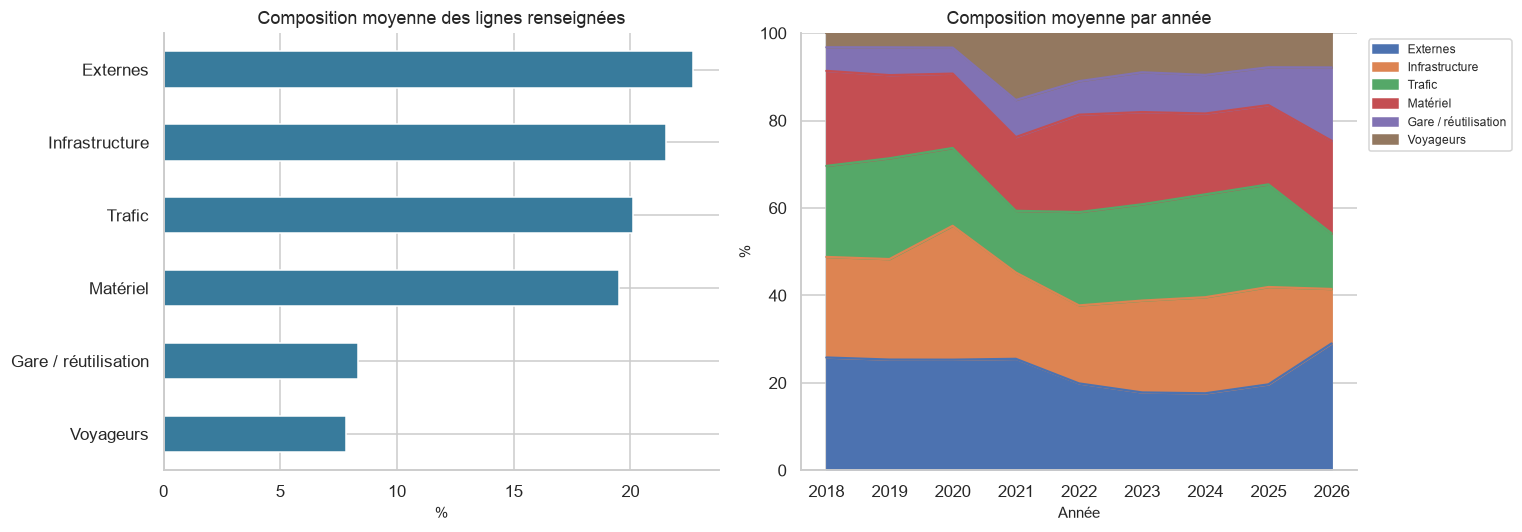

In [18]:
cause_ok = np.isclose(df.somme_causes, 100, atol=.1) & df[CAUSES].ge(0).all(axis=1) & df[CAUSES].le(100).all(axis=1)
cause_data = df.loc[cause_ok].copy()
print(f'{len(cause_data):,} lignes utilisées sur {len(df):,} pour comparer les compositions.')
display(pd.DataFrame({'Moyenne des lignes (%)': cause_data[CAUSES].mean(),
                      'Médiane (%)': cause_data[CAUSES].median(),
                      '% lignes à zéro': cause_data[CAUSES].eq(0).mean().mul(100)}).rename(index=LABELS))
print('Sommes non nulles éloignées de 100 :')
display(df.loc[audit['Somme causes ni 0 ni 100 (tolérance 0,1 pt)'], KEY + CAUSES + ['somme_causes']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_cause = {'cause_externe': 'Externes', 'cause_infra': 'Infrastructure', 'cause_trafic': 'Trafic',
               'cause_materiel': 'Matériel', 'cause_gare': 'Gare / réutilisation', 'cause_voyageurs': 'Voyageurs'}
cause_data[CAUSES].mean().rename(index=short_cause).sort_values().plot.barh(ax=axes[0], color='#387b9c')
axes[0].set(title='Composition moyenne des lignes renseignées', xlabel='%', ylabel='')
cause_data.groupby('annee')[CAUSES].mean().rename(columns=short_cause).plot.area(ax=axes[1], stacked=True)
axes[1].set(title='Composition moyenne par année', xlabel='Année', ylabel='%', ylim=(0, 100))
axes[1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
showfig(fig)

## 9. Relations entre variables

Les corrélations de Spearman résument les associations monotones des lignes agrégées. Elles ne démontrent pas une causalité. Les compteurs partagent un effet de volume et les causes une contrainte de somme. Des taux sont donc inclus pour séparer partiellement volume et fréquence. Les mêmes liaisons réapparaissent chaque mois : les observations ne sont pas indépendantes.

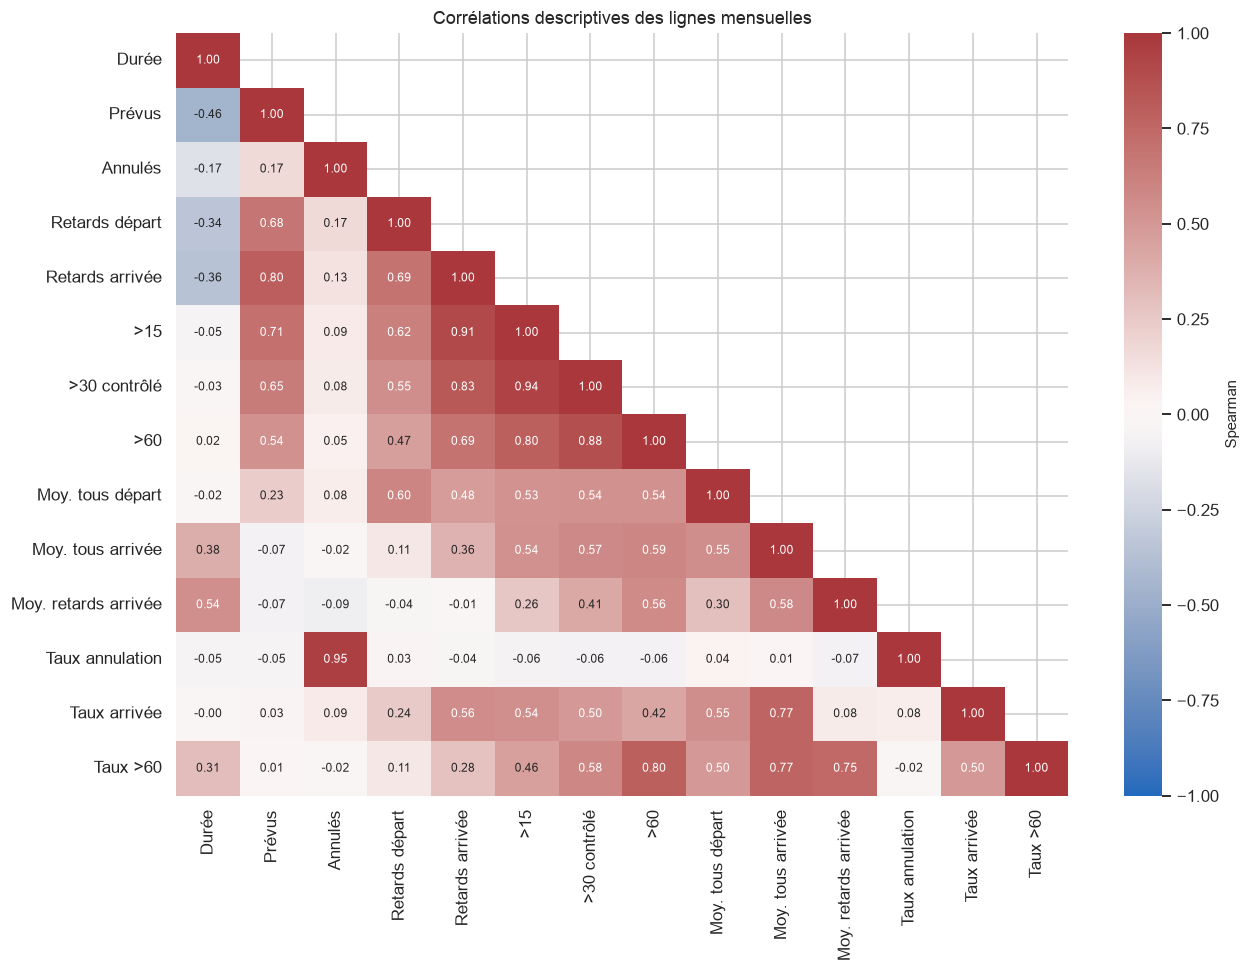

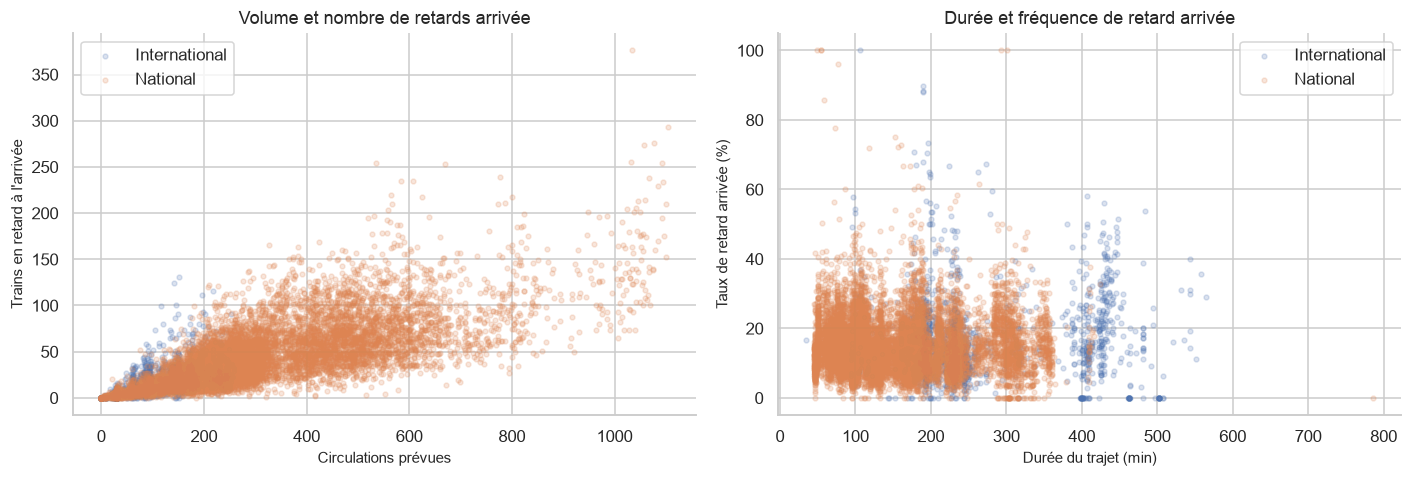

Spearman
annules        taux_annulation     0.954
n15            n30                 0.943
retard_arr     n15                 0.908
n30            n60                 0.878
retard_arr     n30                 0.832
prevus         retard_arr          0.804
n15            n60                 0.797
n60            taux60              0.795
moy_tous_arr   taux_arr            0.772
               taux60              0.766
moy_retard_arr taux60              0.750
prevus         n15                 0.706

In [19]:
corr_cols = ['duree', 'prevus', 'annules', 'retard_dep', 'retard_arr', 'n15', 'n30', 'n60',
              'moy_tous_dep', 'moy_tous_arr', 'moy_retard_arr', 'taux_annulation', 'taux_arr', 'taux60']
corr_data = df[corr_cols].copy()
# Afficher les données brutes, mais ne pas laisser les compteurs >30 incohérents déterminer la corrélation.
corr_data.loc[~strict30, 'n30'] = np.nan
corr = corr_data.corr(method='spearman')
short_labels = {'duree': 'Durée', 'prevus': 'Prévus', 'annules': 'Annulés', 'retard_dep': 'Retards départ',
                'retard_arr': 'Retards arrivée', 'n15': '>15', 'n30': '>30 contrôlé', 'n60': '>60',
                'moy_tous_dep': 'Moy. tous départ', 'moy_tous_arr': 'Moy. tous arrivée',
                'moy_retard_arr': 'Moy. retards arrivée', 'taux_annulation': 'Taux annulation',
                'taux_arr': 'Taux arrivée', 'taux60': 'Taux >60'}
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr.rename(index=short_labels, columns=short_labels), mask=np.triu(np.ones_like(corr, dtype=bool), 1),
            cmap='vlag', vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 8}, ax=ax,
            cbar_kws={'label': 'Spearman'})
ax.set_title('Corrélations descriptives des lignes mensuelles')
showfig(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, x, y, title in [
    (axes[0], 'prevus', 'retard_arr', 'Volume et nombre de retards arrivée'),
    (axes[1], 'duree', 'taux_arr', 'Durée et fréquence de retard arrivée')]:
    for service, part in df.groupby('service'):
        ax.scatter(part[x], part[y], s=10, alpha=.2, label=service, rasterized=True)
    ax.set(title=title, xlabel=LABELS.get(x, x), ylabel=LABELS.get(y, 'Taux de retard arrivée (%)'))
    ax.legend()
showfig(fig)

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().rename('Spearman').to_frame()
pairs = pairs.loc[pairs.Spearman.abs().sort_values(ascending=False).index]
display(pairs.head(12))

## 10. Commentaires et information textuelle

La présence de commentaires dépend fortement de la période et de la liaison. Les textes répétés peuvent décrire le même incident sur plusieurs liaisons : ce ne sont pas des incidents indépendants. Les recherches de mots ci-dessous comptent les **commentaires contenant un motif**, pas les événements.

,lignes,commentaires,% avec commentaire
annee,,,
2018,1560,457,29.295
2019,1476,241,16.328
2020,1476,0,0.000
2021,1449,0,0.000
2022,1467,0,0.000
2023,1446,0,0.000
2024,1450,0,0.000
2025,1494,0,0.000
2026,1089,0,0.000


698 commentaires renseignés, 302 textes distincts.


,Longueur en caractères
count,698.000
mean,547.845
std,532.431
min,6.000
25%,85.000
50%,227.000
75%,941.000
95%,"1,552.050"
max,"2,678.000"


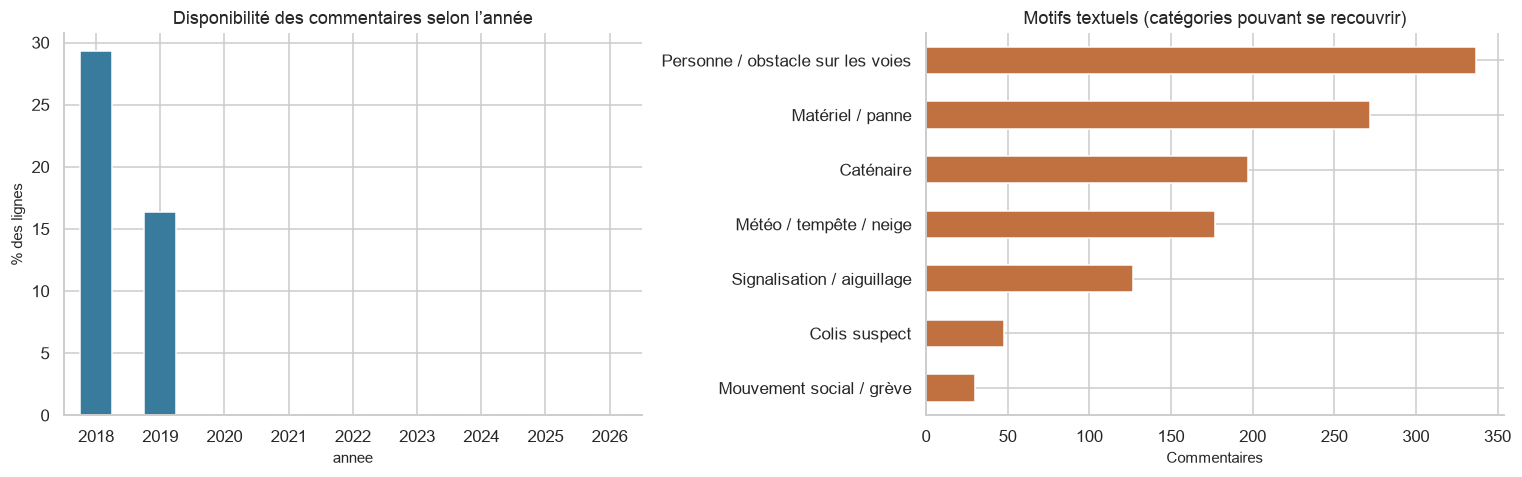

,Nombre de répétitions
comment_arrivee,
"Ce mois-ci, l'OD a été touchée par les incidents suivants: \nLe 3 : Avarie à la caténaire à l’entrée de la gare de Paris Montparnasse (46 TGV ; 476mn)\nLe 6 : épisode neigeux sur toute la France (187 TGV ; 18980mn ; 23 suppressions)\nLe 7 : épisode neigeux sur toute la France (134 TGV ; 6294mn ; 77 suppressions)\nLe 8 : épisode neigeux sur toute la France (166 TGV ; 2814mn ; 30 suppressions)\nLe 9 : épisode neigeux sur toute la France (151 TGV ; 2830mn ; 15 suppressions)\nLe 15 : Incident caténaire à l’entrée de la gare de Paris Montparnasse (78 TGV ; 2349mn ; 15 suppressions)\nLe 15 : Dérangement d’installation sur la ligne grande vitesse (22 TGV ; 672mn)\nLe 21 : Présences de Chèvres aux abords de la ligne grande vitesse à Marcoussis (15 TGV ; 292mn)\nLe 21 : Avarie Matérielle sur la ligne grande vitesse au niveau de St Leger (62 TGV ; 2150mn)\nLe 28 : Bâche dans la caténaire à l’entrée de la gare de Paris Montparnasse (28 TGV ; 605mn)",34
Accidents de personne,29
"Heurt de personnes à Vianges, Heurt animal Cuy, heurt chevreuil Lacour d'arcenay, dérangement Yerres, disjonction cluny, Fort impact sur LN1 tronçon central",19
"Heurt d'une personne à Paris Bercy, limitation vitesse 6909 sur LN1, dérangement vers Montanay accès LN1, heurt de personne à Maisons Alfort, Dérangement d'installation vers Macon",16
"2 accidents de personne, 2 LTV impactantes Lapeyrouse et Venissieux, 3 incidents marériel important sur LN1, 3 dérangements (aiguillage et caténaire) sur LN1, une alerte vent violent à lapalud",15
"Accident de personne à chevry, restitution tardive tx Heyrieux, déraillement bourreuse à Vénissieux, incendie sous station de manduel",14


Exemple de commentaire — 2018-12 STRASBOURG → NANTES
05/12 : 5488?  Non-respect marche tracée (17’) 
07/12 : 5488? Absence tension en ligne à CGV (201’) + 5487? Traversées de voies à Antony (93’)
23/12 : 5488? Signal d’alarme (29‘) 
24/12 : 5487? Moutons sur les voies à Noyen (24‘)


In [20]:
comments = df.comment_arrivee.dropna()
comments = comments.loc[comments.str.strip().ne('')]
comment_presence = df.index.isin(comments.index)
comment_year = df.assign(comment_present=comment_presence).groupby('annee').agg(
    lignes=('route_id', 'size'), commentaires=('comment_present', 'sum'))
comment_year['% avec commentaire'] = 100 * comment_year.commentaires / comment_year.lignes
display(comment_year)
print(f'{len(comments)} commentaires renseignés, {comments.nunique()} textes distincts.')
display(comments.str.len().describe(percentiles=[.25, .5, .75, .95]).to_frame('Longueur en caractères'))

def normalize_text(text):
    return ''.join(c for c in unicodedata.normalize('NFKD', str(text).lower()) if not unicodedata.combining(c))

normalized = comments.map(normalize_text)
patterns = {'Météo / tempête / neige': r'meteo|tempete|neige|intemperie|orage',
            'Caténaire': r'catenaire', 'Signalisation / aiguillage': r'signalisation|aiguill',
            'Personne / obstacle sur les voies': r'personne|obstacle',
            'Colis suspect': r'colis suspect', 'Mouvement social / grève': r'greve|mouvement social',
            'Matériel / panne': r'materiel|panne'}
keywords = pd.Series({name: normalized.str.contains(pattern, regex=True).sum()
                      for name, pattern in patterns.items()}, name='Commentaires contenant le motif')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
comment_year['% avec commentaire'].plot.bar(ax=axes[0], color='#387b9c', rot=0)
axes[0].set(title='Disponibilité des commentaires selon l’année', ylabel='% des lignes')
keywords.sort_values().plot.barh(ax=axes[1], color='#c0713f')
axes[1].set(title='Motifs textuels (catégories pouvant se recouvrir)', xlabel='Commentaires', ylabel='')
showfig(fig)
display(comments.value_counts().head(6).rename('Nombre de répétitions').to_frame())
example_index = comments.str.len().sort_values().index[len(comments) // 2]
print('Exemple de commentaire —', df.loc[example_index, 'date'].strftime('%Y-%m'), df.loc[example_index, 'liaison'])
print(comments.loc[example_index])

## 11. Ce qui ressort de l'exploration

In [21]:
neg_dates = df.loc[audit['Compteur négatif'], 'date'].dt.strftime('%Y-%m').unique()
full_routes = int(monthly_presence.all(axis=1).sum())
common_equality = same_by_month.loc['2018-08':'2019-04']
display(Markdown(f"""
### Structure

- **{len(raw):,} lignes, {raw.shape[1]} colonnes et {df.date.nunique()} mois**. Clé métier unique et couverture temporelle globale continue.
- **{df.liaison.nunique()} liaisons orientées**, ou {df.route_id.nunique()} en séparant le service. Seulement {full_routes} liaisons × service sont présentes tous les mois.
- Les volumes sont inégaux : les 10 premières liaisons représentent **{top10_share:.1%}** des circulations prévues déclarées. La médiane de volume par ligne est {df.prevus.median():.0f}, contre une moyenne de {df.prevus.mean():.1f}.

### Qualité et changements de définition possibles

- **{negative_counts} compteurs négatifs**, localisés sur {', '.join(neg_dates)} ; **{threshold_fail} violations > 60 / > 30**, sur {', '.join(bad_months)}. La série > 30 min de cette période doit être vérifiée avant usage.
- **{int(audit['Annulés > prévus'].sum())} lignes avec plus d'annulations que de circulations prévues** et {int(df.prevus.eq(0).sum())} lignes sans prévision. Les ratios restent manquants lorsque leur dénominateur ou leur population est incohérent.
- Le retard moyen de tous les trains à l'arrivée descend jusqu'à **{df.moy_tous_arr.min():.1f} min**. Les petites valeurs négatives peuvent être des avances ; les valeurs extrêmes et les moyennes négatives des trains en retard sont à investiguer.
- Entre août 2018 et avril 2019, la moyenne « > 15 min » est identique à la moyenne de tous les trains sur **{common_equality.mean():.0f} %** des lignes en moyenne mensuelle. Son comportement change en mai 2019. Le champ ne doit pas être interprété uniformément sans validation de la source.
- **{int(pair_service.gt(1).sum())} liaisons changent ou cumulent des étiquettes de service**. Plusieurs trajets entre gares françaises portent International en juillet–septembre 2025 ; Paris–Barcelone porte National à partir d'octobre 2025.
- Les deux commentaires annulations/départ sont entièrement vides. Les **{len(comments)} commentaires à l'arrivée** sont concentrés en 2018–2019 : leur absence ensuite n'indique pas l'absence d'incidents.
- **{int(audit['Six causes à zéro malgré des retards arrivée'].sum())} lignes ont six causes à zéro malgré des retards** ; {int(audit['Somme causes ni 0 ni 100 (tolérance 0,1 pt)'].sum())} compositions non nulles s'écartent de 100 de plus de 0,1 point.

### Conséquences pour la suite

- Comparer des taux en agrégeant les numérateurs et dénominateurs des **mêmes lignes** ; contrôler le service, le sens du trajet, le volume et la couverture.
- Utiliser la même fenêtre calendaire pour comparer 2026 aux autres années. Vérifier les résultats sur le panel constant.
- Conserver les alertes et la provenance des éventuelles corrections. Ne pas remplacer automatiquement les absences, les zéros ou les compteurs négatifs.
- Pour une prédiction, privilégier une séparation chronologique et calculer les variables explicatives à partir du passé. Les causes et compteurs du même mois sont des résultats contemporains ; ils peuvent créer une fuite d'information si la cible est le retard de ce mois.
- Le fichier ne permet pas d'identifier des trains uniques, ni la distribution individuelle des retards, ni un effet causal. Une corrélation sur les lignes mensuelles ne suffit pas pour expliquer les retards.

**Objets utiles pour continuer :** `raw` (source), `df` (alias et taux dérivés), `stats`, `audit`, `review_rows`, `coverage`, `monthly`, `ranked`, `paired`, `cause_data`.
"""))


### Structure

- **12,907 lignes, 26 colonnes et 105 mois**. Clé métier unique et couverture temporelle globale continue.
- **130 liaisons orientées**, ou 146 en séparant le service. Seulement 112 liaisons × service sont présentes tous les mois.
- Les volumes sont inégaux : les 10 premières liaisons représentent **19.8%** des circulations prévues déclarées. La médiane de volume par ligne est 231, contre une moyenne de 273.4.

### Qualité et changements de définition possibles

- **43 compteurs négatifs**, localisés sur 2025-01, 2025-02, 2025-03 ; **354 violations > 60 / > 30**, sur 2025-01, 2025-02, 2025-03. La série > 30 min de cette période doit être vérifiée avant usage.
- **63 lignes avec plus d'annulations que de circulations prévues** et 73 lignes sans prévision. Les ratios restent manquants lorsque leur dénominateur ou leur population est incohérent.
- Le retard moyen de tous les trains à l'arrivée descend jusqu'à **-472.6 min**. Les petites valeurs négatives peuvent être des avances ; les valeurs extrêmes et les moyennes négatives des trains en retard sont à investiguer.
- Entre août 2018 et avril 2019, la moyenne « > 15 min » est identique à la moyenne de tous les trains sur **100 %** des lignes en moyenne mensuelle. Son comportement change en mai 2019. Le champ ne doit pas être interprété uniformément sans validation de la source.
- **16 liaisons changent ou cumulent des étiquettes de service**. Plusieurs trajets entre gares françaises portent International en juillet–septembre 2025 ; Paris–Barcelone porte National à partir d'octobre 2025.
- Les deux commentaires annulations/départ sont entièrement vides. Les **698 commentaires à l'arrivée** sont concentrés en 2018–2019 : leur absence ensuite n'indique pas l'absence d'incidents.
- **80 lignes ont six causes à zéro malgré des retards** ; 10 compositions non nulles s'écartent de 100 de plus de 0,1 point.

### Conséquences pour la suite

- Comparer des taux en agrégeant les numérateurs et dénominateurs des **mêmes lignes** ; contrôler le service, le sens du trajet, le volume et la couverture.
- Utiliser la même fenêtre calendaire pour comparer 2026 aux autres années. Vérifier les résultats sur le panel constant.
- Conserver les alertes et la provenance des éventuelles corrections. Ne pas remplacer automatiquement les absences, les zéros ou les compteurs négatifs.
- Pour une prédiction, privilégier une séparation chronologique et calculer les variables explicatives à partir du passé. Les causes et compteurs du même mois sont des résultats contemporains ; ils peuvent créer une fuite d'information si la cible est le retard de ce mois.
- Le fichier ne permet pas d'identifier des trains uniques, ni la distribution individuelle des retards, ni un effet causal. Une corrélation sur les lignes mensuelles ne suffit pas pour expliquer les retards.

**Objets utiles pour continuer :** `raw` (source), `df` (alias et taux dérivés), `stats`, `audit`, `review_rows`, `coverage`, `monthly`, `ranked`, `paired`, `cause_data`.


### Exploration libre

Les cellules suivantes sont prêtes pour examiner une liaison ou les lignes signalées. Elles affichent un extrait ; les DataFrames complets restent accessibles en mémoire.

In [22]:
# Modifier ces deux valeurs pour suivre une autre liaison.
DEPART = 'PARIS MONTPARNASSE'
ARRIVEE = 'BORDEAUX ST JEAN'
selection = df.loc[df.depart.eq(DEPART) & df.arrivee.eq(ARRIVEE)].sort_values('date')
display(selection[['date', 'service', 'duree', 'prevus', 'annules',
                   'retard_arr', 'taux_arr', 'moy_tous_arr', 'n30', 'n60']].tail(18))
# Exemple : review_rows.query('annee == 2025')[KEY + COUNTS + ['alertes']]

,date,service,duree,prevus,annules,retard_arr,taux_arr,moy_tous_arr,n30,n60
10777,2025-04-01,National,144,1018,1,74,7.276,3.036,20,4
10821,2025-05-01,National,152,991,15,79,8.094,3.865,32,12
10944,2025-06-01,National,149,1008,0,146,14.484,6.408,47,12
11154,2025-07-01,National,146,1060,0,108,10.189,4.166,35,12
11212,2025-08-01,National,146,1046,2,136,13.027,5.196,72,15
11337,2025-09-01,National,139,1013,5,129,12.798,7.638,52,35
11473,2025-10-01,National,139,1050,1,104,9.914,3.732,34,11
11601,2025-11-01,National,140,957,0,123,12.853,4.625,40,13
11744,2025-12-01,National,140,1005,1,129,12.849,5.624,44,13
11900,2026-01-01,National,142,1016,18,165,16.533,5.082,66,21
